
# Trader Performance vs Bitcoin Market Sentiment Analysis
# Part 1: Import Libraries, Load Data, Cleaning,
# Feature Engineering


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, pearsonr
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)


# Load Dataset

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")


# Clean Column Names

trades.columns = trades.columns.str.strip()
sentiment.columns = sentiment.columns.str.strip()


# Rename Columns

trades.rename(columns={
    "Execution Price":"ExecutionPrice",
    "Size USD":"TradeSizeUSD",
    "Closed PnL":"ClosedPnL"
}, inplace=True)

sentiment.rename(columns={
    "classification":"Classification"
}, inplace=True)


# Preview

print("="*60)
print("Historical Trade Dataset")
print("="*60)
print(trades.head())

print("\n")

print("="*60)
print("Fear & Greed Dataset")
print("="*60)
print(sentiment.head())


# Dataset Information

print("\nTrade Dataset Information")
print(trades.info())

print("\nSentiment Dataset Information")
print(sentiment.info())


# Shape

print("\nTrade Dataset Shape :", trades.shape)
print("Sentiment Dataset Shape :", sentiment.shape)


# Missing Values

print("\nTrade Dataset Missing Values")

print(trades.isnull().sum())

print("\nSentiment Dataset Missing Values")

print(sentiment.isnull().sum())


# Remove Duplicate Rows

print("\nDuplicate Rows :", trades.duplicated().sum())

trades.drop_duplicates(inplace=True)

print("Duplicate Rows After Removal :", trades.duplicated().sum())


# ==========================
# Timestamp Conversion
# ==========================

# Trade Dataset Timestamp (Unix milliseconds)

trades["Timestamp"] = pd.to_datetime(
    trades["Timestamp"],
    unit="ms",
    errors="coerce"
)

trades["TradeDate"] = trades["Timestamp"].dt.normalize()

trades["Year"] = trades["Timestamp"].dt.year
trades["Month"] = trades["Timestamp"].dt.month
trades["MonthName"] = trades["Timestamp"].dt.month_name()
trades["Day"] = trades["Timestamp"].dt.day
trades["Hour"] = trades["Timestamp"].dt.hour


# ==========================
# Sentiment Date Conversion
# ==========================

# Rename column if not already renamed
sentiment.rename(
    columns={"classification": "Classification"},
    inplace=True
)

# Convert sentiment date
sentiment["date"] = pd.to_datetime(
    sentiment["date"],
    errors="coerce"
)

# Create TradeDate in the same format as trades
sentiment["TradeDate"] = sentiment["date"].dt.normalize()

# Remove invalid dates
sentiment = sentiment.dropna(subset=["TradeDate"])

# Remove duplicate dates (keep first occurrence)
sentiment = sentiment.drop_duplicates(subset=["TradeDate"])

# Verify date ranges
print("\nTrades Date Range:")
print(trades["TradeDate"].min(), "to", trades["TradeDate"].max())

print("\nSentiment Date Range:")
print(sentiment["TradeDate"].min(), "to", sentiment["TradeDate"].max())

# Check overlapping dates
common_dates = set(trades["TradeDate"]).intersection(set(sentiment["TradeDate"]))

print("\nCommon Dates:", len(common_dates))

# Numeric Conversion

numeric_columns = [
    "ExecutionPrice",
    "TradeSizeUSD",
    "ClosedPnL"
]

for col in numeric_columns:

    trades[col] = pd.to_numeric(
        trades[col],
        errors="coerce"
    )


# Remove Missing Values

trades.dropna(
    subset=numeric_columns + ["Timestamp"],
    inplace=True
)


# Feature Engineering

trades["AbsolutePnL"] = trades["ClosedPnL"].abs()

trades["ProfitFlag"] = (
    trades["ClosedPnL"] > 0
).astype(int)

trades["LossFlag"] = (
    trades["ClosedPnL"] < 0
).astype(int)

trades["TradeCategory"] = np.where(
    trades["ClosedPnL"] > 0,
    "Profit",
    "Loss"
)

average_trade = trades["TradeSizeUSD"].mean()

trades["LargeTrade"] = np.where(
    trades["TradeSizeUSD"] > average_trade,
    "Yes",
    "No"
)

trades["TradeSizeCategory"] = pd.qcut(
    trades["TradeSizeUSD"],
    q=4,
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large"
    ]
)


# Encode Direction

encoder = LabelEncoder()

trades["DirectionEncoded"] = encoder.fit_transform(
    trades["Direction"]
)


# Summary Statistics

print("\nSummary Statistics")

print(trades.describe())


# Unique Values

print("\nNumber of Coins :", trades["Coin"].nunique())

print("Coins")

print(trades["Coin"].unique())

print("\nNumber of Traders :", trades["Account"].nunique())


# Final Dataset Check

print("\nFinal Dataset Shape")

print(trades.shape)

print("\nProcessed Dataset")

print(trades.head())


# Check Sentiment Dataset

print("\nProcessed Sentiment Dataset")

print(sentiment.head())

print("\nSentiment Categories")

print(sentiment["Classification"].value_counts())

Historical Trade Dataset
                                      Account  Coin  ExecutionPrice  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107          7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107          7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107          7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107          7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107          7.9894   

   Size Tokens  TradeSizeUSD Side     Timestamp IST  Start Position Direction  \
0       986.87       7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00        127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09       1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98       1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73         69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   ClosedPnL                                   Transaction Ha

Part 2 : Merge Dataset & Exploratory Data Analysis


Merged Dataset Shape
(184263, 30)

Unique Dates: 6

Sentiment Distribution:
Classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64
Merged Dataset Overview
Shape : (184263, 30)
Unique Traders : 32
Unique Coins : 239
Unique Dates : 6

Sentiment Distribution
Classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

First Five Rows


,Account,Coin,ExecutionPrice,Size Tokens,TradeSizeUSD,Side,Timestamp IST,Start Position,Direction,ClosedPnL,...,Day,Hour,AbsolutePnL,ProfitFlag,LossFlag,TradeCategory,LargeTrade,TradeSizeCategory,DirectionEncoded,Classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,27,3,0.0,0,0,Loss,Yes,Very Large,1,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,27,3,0.0,0,0,Loss,No,Small,1,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,27,3,0.0,0,0,Loss,No,Large,1,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,27,3,0.0,0,0,Loss,No,Large,1,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,27,3,0.0,0,0,Loss,No,Small,1,Greed


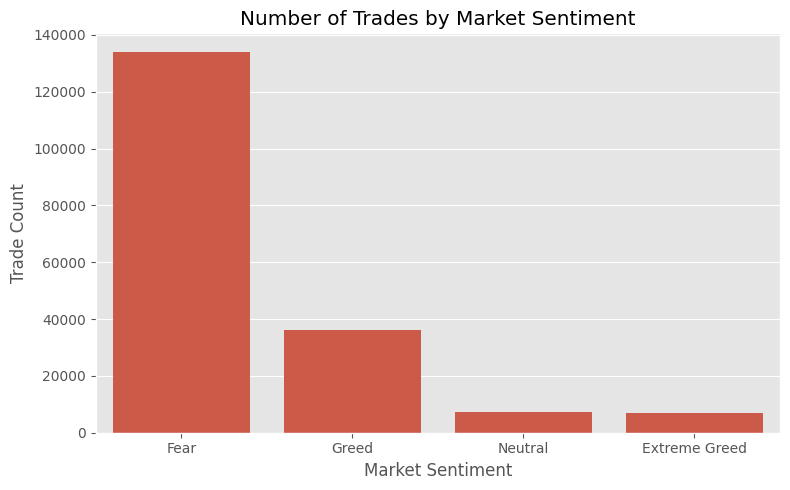

Classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: ClosedPnL, dtype: float64


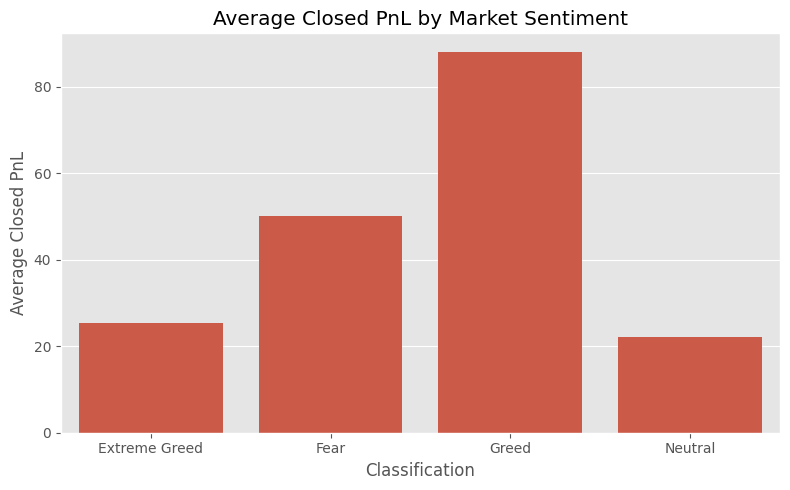

Classification
Extreme Greed    1.769655e+05
Fear             6.699925e+06
Greed            3.189617e+06
Neutral          1.587424e+05
Name: ClosedPnL, dtype: float64


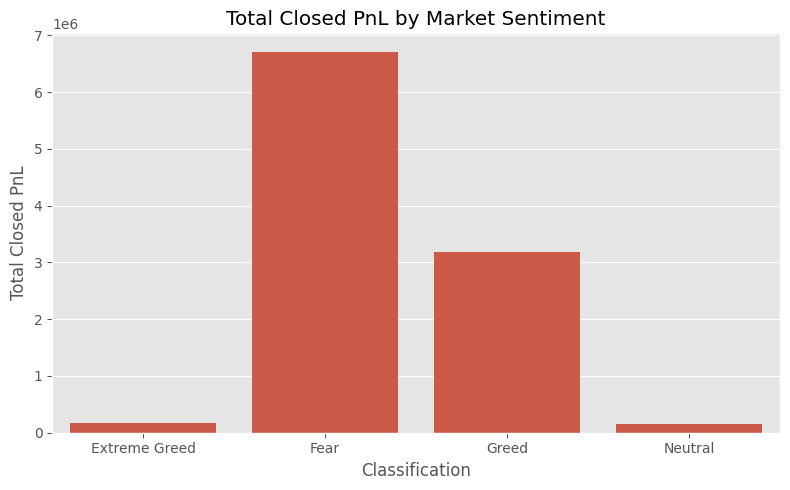

Classification
Extreme Greed    49.008905
Fear             41.514592
Greed            44.647138
Neutral          31.718247
Name: ProfitFlag, dtype: float64


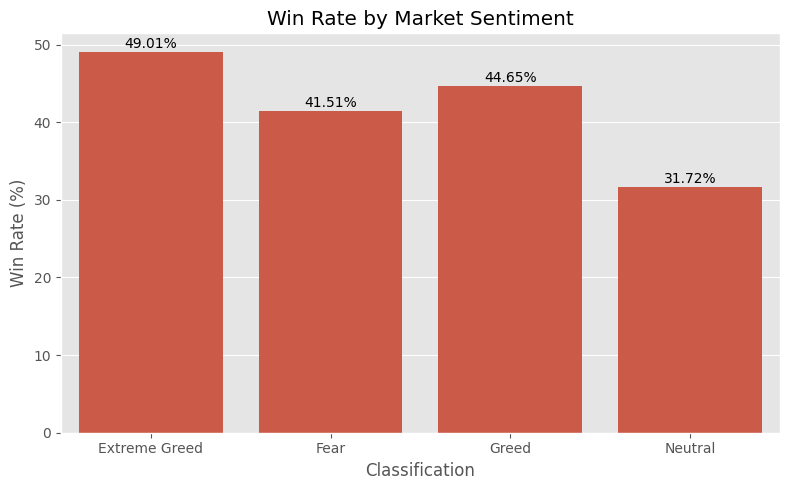

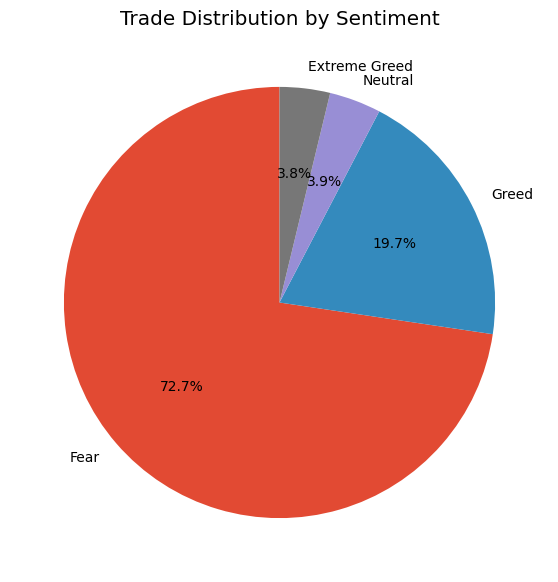

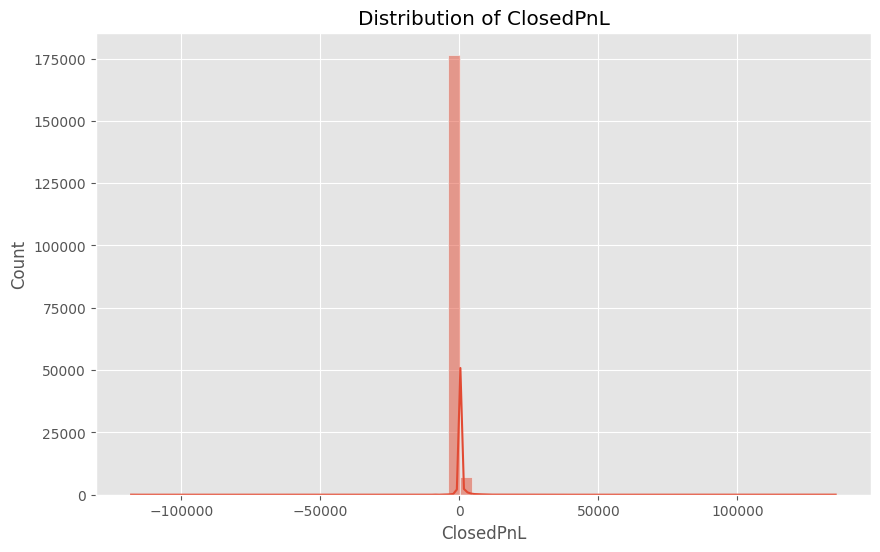

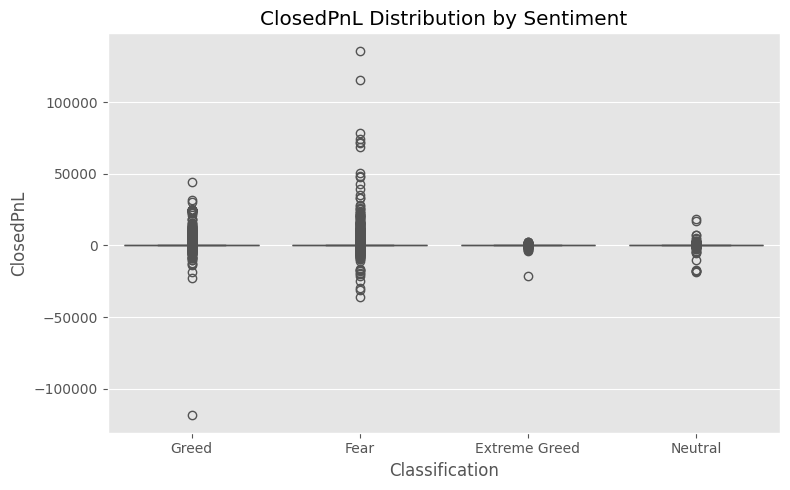

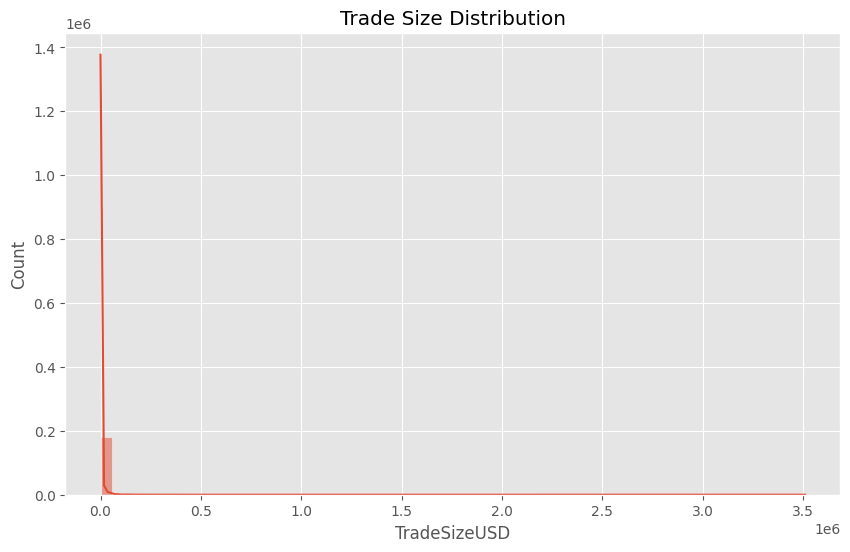

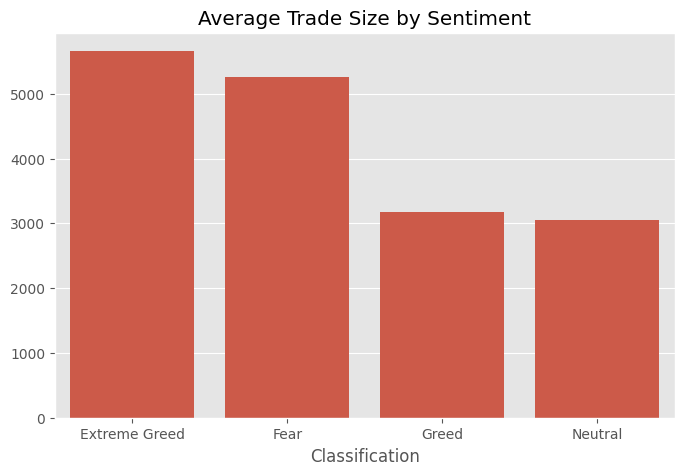

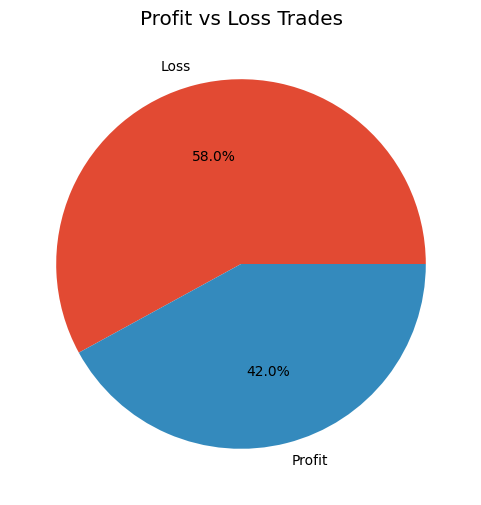

                TotalTrades  AveragePnL  MedianPnL      TotalPnL  \
Classification                                                     
Greed                 36289   87.894859        0.0  3.189617e+06   
Fear                 133871   50.047622        0.0  6.699925e+06   
Extreme Greed          6962   25.418772        0.0  1.769655e+05   
Neutral                7141   22.229713        0.0  1.587424e+05   

                      MaxPnL        MinPnL  AverageTradeSize  \
Classification                                                 
Greed            44223.45187 -117990.10410       3182.883845   
Fear            135329.09010  -35681.74723       5259.977837   
Extreme Greed     2500.95750  -21524.40000       5660.265764   
Neutral          18282.19011  -18360.67007       3058.848110   

                TotalTradeVolume    WinRate  UniqueTraders  
Classification                                              
Greed               1.155037e+08  44.647138             29  
Fear                7.0

Account                     0x083384f897ee0f19899168e3b1bec365f52a9012
Coin                                                               ETH
ExecutionPrice                                                  1570.1
Size Tokens                                                   186.5296
TradeSizeUSD                                                 292870.12
Side                                                               BUY
Timestamp IST                                         12-04-2025 12:31
Start Position                                               -203.3554
Direction                                                  Close Short
ClosedPnL                                                  135329.0901
Transaction Hash     0x5dabcff879b7dd6b4fa7042162f3b00202d8003a722e...
Order ID                                                   85971520603
Crossed                                                          False
Fee                                                          29.287012
Trade 

Highest Loss Trade


Account                     0x083384f897ee0f19899168e3b1bec365f52a9012
Coin                                                               ETH
ExecutionPrice                                                  4041.0
Size Tokens                                                    201.565
TradeSizeUSD                                                 814524.17
Side                                                               BUY
Timestamp IST                                         06-12-2024 23:15
Start Position                                               -559.2834
Direction                                                  Close Short
ClosedPnL                                                 -117990.1041
Transaction Hash     0x708d15cf3ed40382ad00041894851a0203b8006ff533...
Order ID                                                   53292414040
Crossed                                                          False
Fee                                                          81.452416
Trade 

ClosedPnL Statistics
count    184263.000000
mean         55.492690
std         937.857954
min     -117990.104100
25%           0.000000
50%           0.000000
75%           6.602400
max      135329.090100
Name: ClosedPnL, dtype: float64
Trade Size Statistics
count    1.842630e+05
mean     4.780733e+03
std      2.690428e+04
min      0.000000e+00
25%      1.875300e+02
50%      5.927400e+02
75%      2.032705e+03
max      3.509753e+06
Name: TradeSizeUSD, dtype: float64
PART 2 COMPLETED SUCCESSFULLY


In [ ]:
# Keep only valid sentiment records
sentiment_clean = (
    sentiment[['TradeDate', 'Classification']]
    .dropna()
    .drop_duplicates(subset='TradeDate')
)

# Merge only matching dates
merged_df = pd.merge(
    trades,
    sentiment_clean,
    on='TradeDate',
    how='inner'
)

print("=" * 60)
print("Merged Dataset Shape")
print("=" * 60)
print(merged_df.shape)

print("\nUnique Dates:", merged_df["TradeDate"].nunique())
print("\nSentiment Distribution:")
print(merged_df["Classification"].value_counts())

# ==========================================================
# PART 2 : EXPLORATORY DATA ANALYSIS
# ==========================================================

print("="*70)
print("Merged Dataset Overview")
print("="*70)

print("Shape :", merged_df.shape)
print("Unique Traders :", merged_df["Account"].nunique())
print("Unique Coins :", merged_df["Coin"].nunique())
print("Unique Dates :", merged_df["TradeDate"].nunique())

print("\nSentiment Distribution")
print(merged_df["Classification"].value_counts())

print("\nFirst Five Rows")
display(merged_df.head())

plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x="Classification",
    order=merged_df["Classification"].value_counts().index
)

plt.title("Number of Trades by Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Trade Count")

plt.tight_layout()

plt.show()

avg_pnl = merged_df.groupby(
    "Classification"
)["ClosedPnL"].mean()

print(avg_pnl)

plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_pnl.index,
    y=avg_pnl.values
)

plt.title("Average Closed PnL by Market Sentiment")

plt.ylabel("Average Closed PnL")

plt.tight_layout()

plt.show()

total_pnl = merged_df.groupby(
    "Classification"
)["ClosedPnL"].sum()

print(total_pnl)

plt.figure(figsize=(8,5))

sns.barplot(
    x=total_pnl.index,
    y=total_pnl.values
)

plt.title("Total Closed PnL by Market Sentiment")

plt.ylabel("Total Closed PnL")

plt.tight_layout()

plt.show()

win_rate = merged_df.groupby(
    "Classification"
)["ProfitFlag"].mean()*100

print(win_rate)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=win_rate.index,
    y=win_rate.values
)

for i,v in enumerate(win_rate.values):

    ax.text(i,v+0.5,f"{v:.2f}%",ha="center")

plt.title("Win Rate by Market Sentiment")

plt.ylabel("Win Rate (%)")

plt.tight_layout()

plt.show()

trade_count = merged_df["Classification"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    trade_count.values,
    labels=trade_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Trade Distribution by Sentiment")

plt.show()

plt.figure(figsize=(10,6))

sns.histplot(
    merged_df["ClosedPnL"],
    bins=60,
    kde=True
)

plt.title("Distribution of ClosedPnL")

plt.xlabel("ClosedPnL")

plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged_df,
    x="Classification",
    y="ClosedPnL"
)

plt.title("ClosedPnL Distribution by Sentiment")

plt.tight_layout()

plt.show()

plt.figure(figsize=(10,6))

sns.histplot(
    merged_df["TradeSizeUSD"],
    bins=60,
    kde=True
)

plt.title("Trade Size Distribution")

plt.show()

avg_trade = merged_df.groupby(
    "Classification"
)["TradeSizeUSD"].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_trade.index,
    y=avg_trade.values
)

plt.title("Average Trade Size by Sentiment")

plt.show()

profit_loss = merged_df["TradeCategory"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    profit_loss.values,
    labels=profit_loss.index,
    autopct="%1.1f%%"
)

plt.title("Profit vs Loss Trades")

plt.show()


summary = merged_df.groupby("Classification").agg(

    TotalTrades=("Account","count"),

    AveragePnL=("ClosedPnL","mean"),

    MedianPnL=("ClosedPnL","median"),

    TotalPnL=("ClosedPnL","sum"),

    MaxPnL=("ClosedPnL","max"),

    MinPnL=("ClosedPnL","min"),

    AverageTradeSize=("TradeSizeUSD","mean"),

    TotalTradeVolume=("TradeSizeUSD","sum"),

    WinRate=("ProfitFlag","mean"),

    UniqueTraders=("Account","nunique")

)

summary["WinRate"]*=100

summary=summary.sort_values(
    by="AveragePnL",
    ascending=False
)

print(summary)


highest_profit = merged_df.loc[
    merged_df["ClosedPnL"].idxmax()
]

print("Highest Profit Trade")

display(highest_profit)


highest_loss = merged_df.loc[
    merged_df["ClosedPnL"].idxmin()
]

print("Highest Loss Trade")

display(highest_loss)


print("="*60)

print("ClosedPnL Statistics")

print("="*60)

print(
    merged_df["ClosedPnL"].describe()
)

print("="*60)

print("Trade Size Statistics")

print("="*60)

print(
    merged_df["TradeSizeUSD"].describe()
)

print("="*60)

print("PART 2 COMPLETED SUCCESSFULLY")

print("="*60)

Part 3: Visualizations

Direction
Open Long               45564
Close Long              44935
Open Short              32861
Close Short             28091
Sell                    17890
Buy                     14657
Spot Dust Conversion      137
Short > Long               65
Long > Short               54
Auto-Deleveraging           8
Settlement                  1
Name: count, dtype: int64


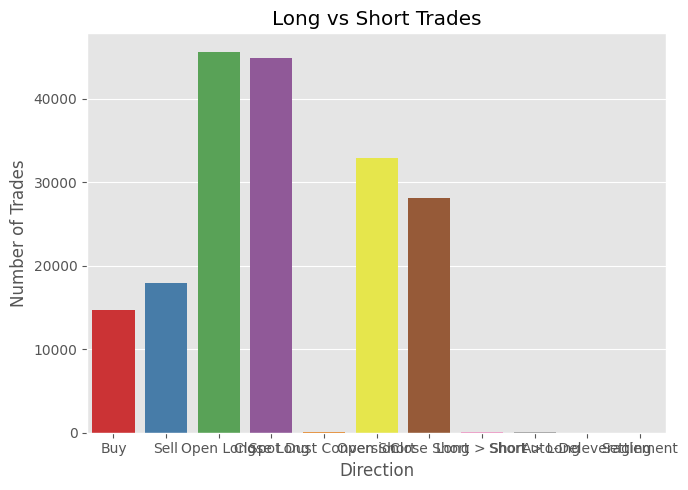

Direction
Auto-Deleveraging       7184.807003
Buy                        0.000000
Close Long                69.191429
Close Short              148.059254
Long > Short              36.362308
Open Long                  0.000000
Open Short                 0.000000
Sell                     161.285380
Settlement               -29.215368
Short > Long             187.568677
Spot Dust Conversion       0.000000
Name: ClosedPnL, dtype: float64


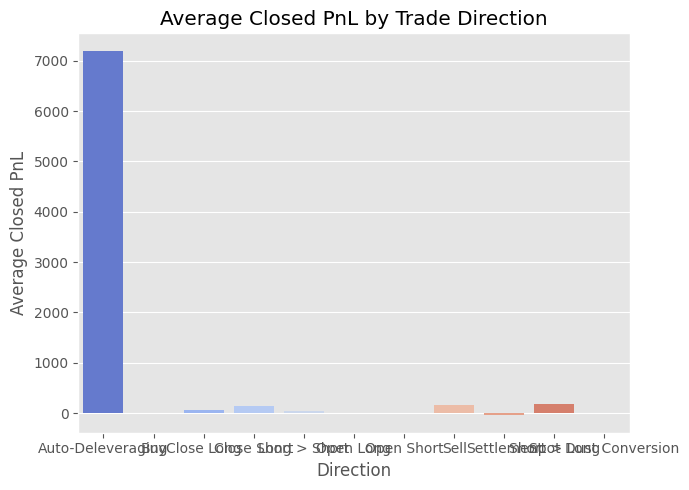

Classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: TradeSizeUSD, dtype: float64


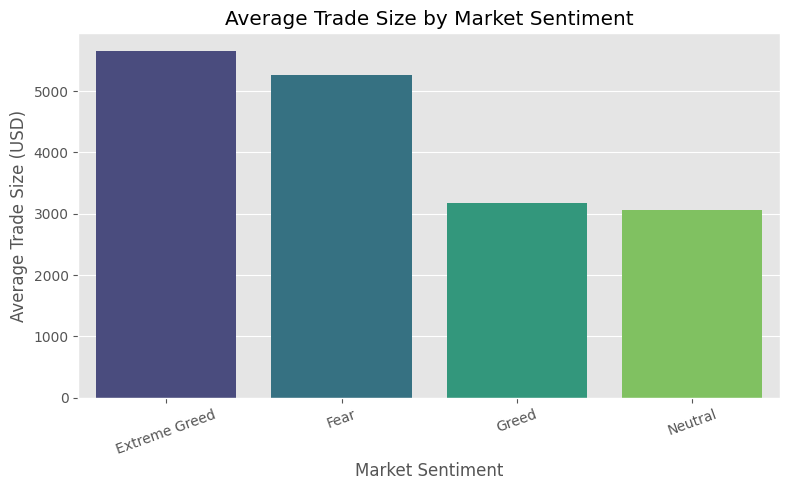

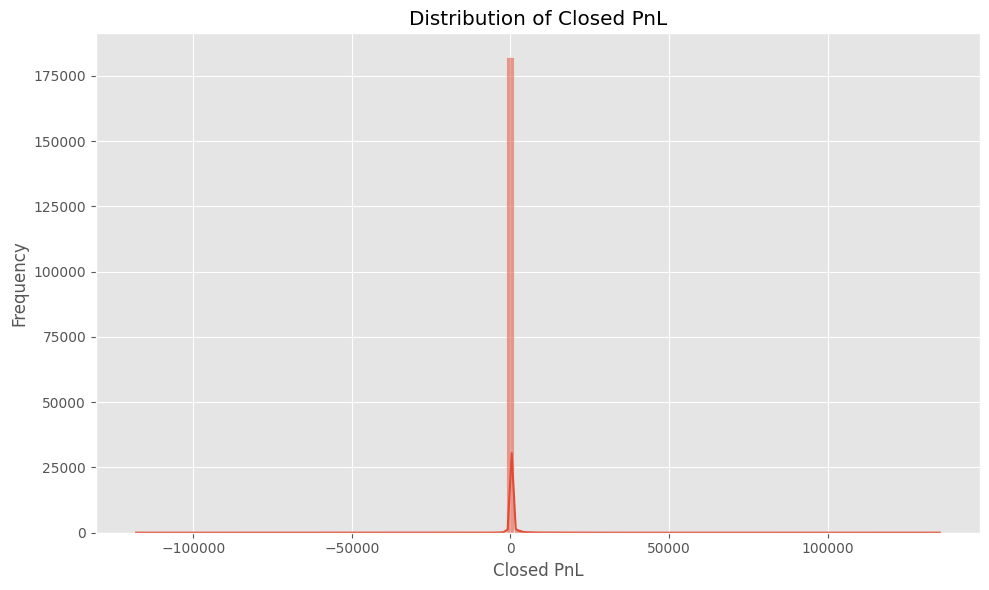

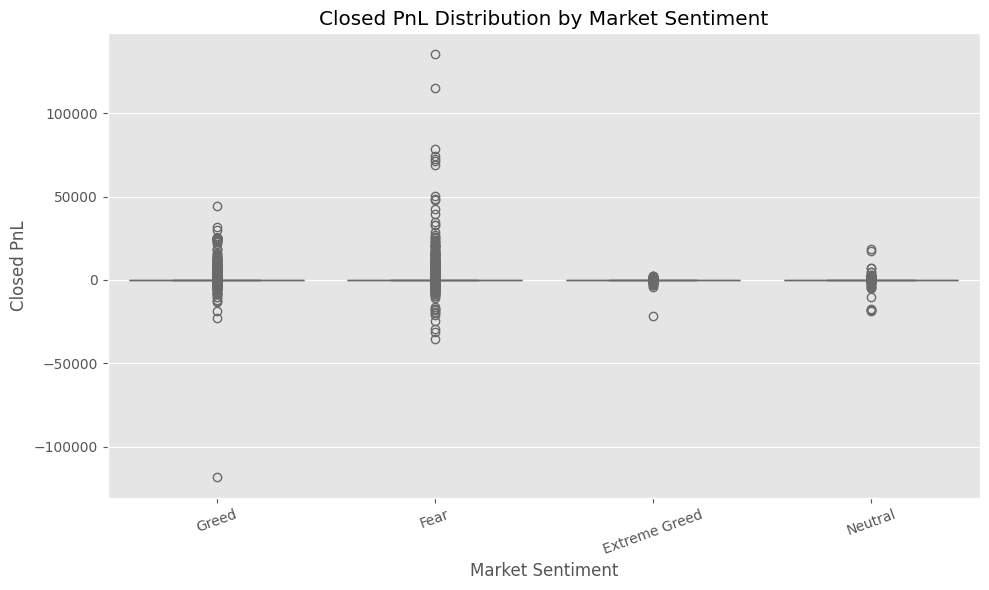

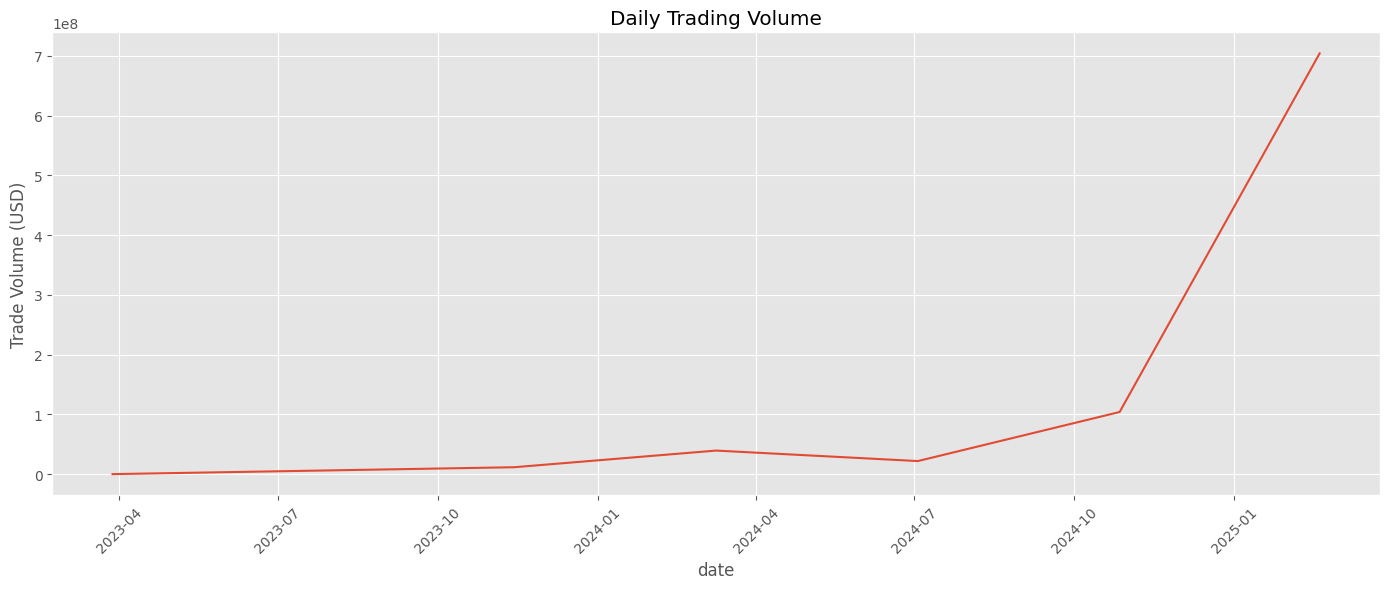

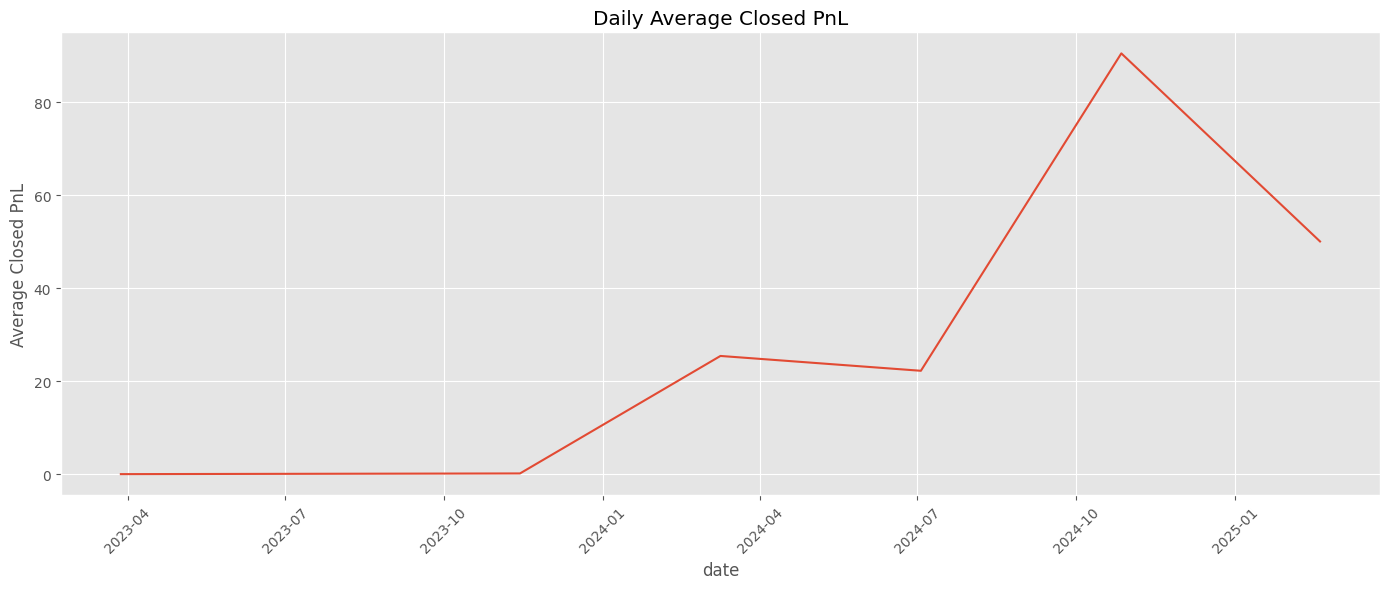

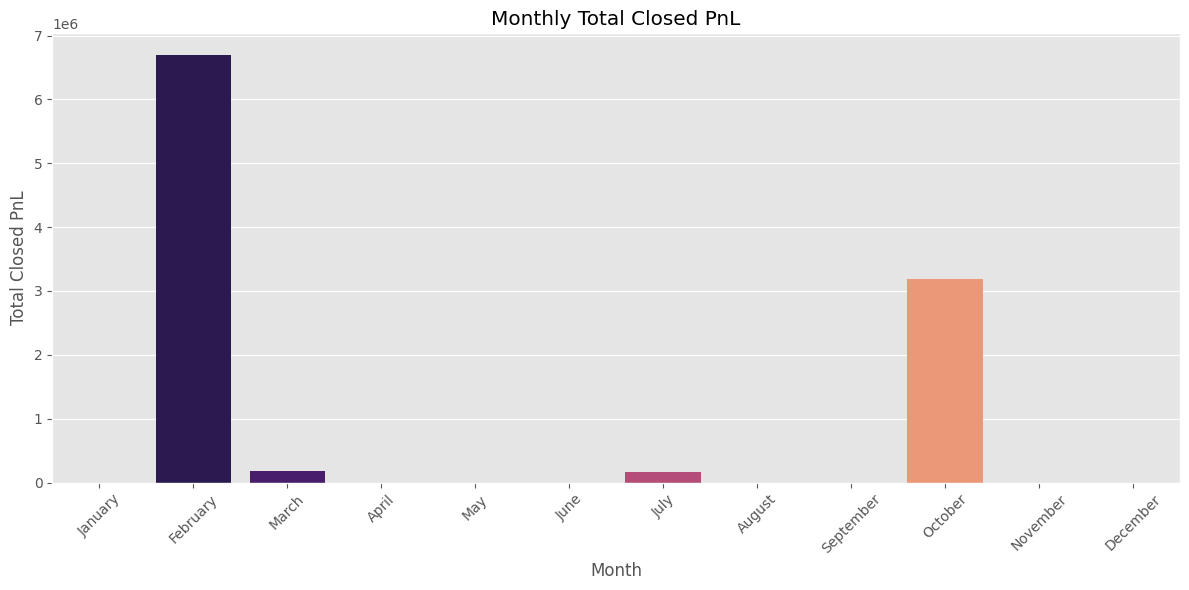

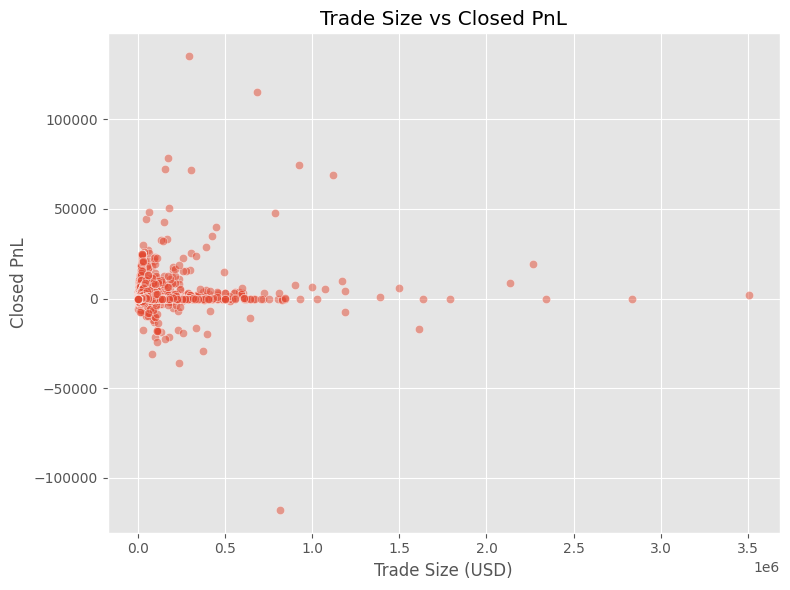

Correlation between Trade Size and Closed PnL : 0.136852861726778

Direction Wise Profit
                      count         mean           sum            max  \
Direction                                                               
Auto-Deleveraging         8  7184.807003  5.747846e+04   18282.190110   
Buy                   14657     0.000000  0.000000e+00       0.000000   
Close Long            44935    69.191429  3.109117e+06   68959.002120   
Close Short           28091   148.059254  4.159133e+06  135329.090100   
Long > Short             54    36.362308  1.963565e+03    1169.859383   
Open Long             45564     0.000000  0.000000e+00       0.000000   
Open Short            32861     0.000000  0.000000e+00       0.000000   
Sell                  17890   161.285380  2.885395e+06   44223.451870   
Settlement                1   -29.215368 -2.921537e+01     -29.215368   
Short > Long             65   187.568677  1.219196e+04   11090.496500   
Spot Dust Conversion    137     0.0

In [ ]:
# Long vs Short Distribution

direction_count = merged_df['Direction'].value_counts()

print(direction_count)

plt.figure(figsize=(7,5))

sns.countplot(
    data=merged_df,
    x='Direction',
    palette='Set1'
)

plt.title("Long vs Short Trades")
plt.xlabel("Direction")
plt.ylabel("Number of Trades")

plt.tight_layout()
plt.show()


# Long vs Short Profit Comparison

direction_profit = merged_df.groupby('Direction')['ClosedPnL'].mean()

print(direction_profit)

plt.figure(figsize=(7,5))

sns.barplot(
    x=direction_profit.index,
    y=direction_profit.values,
    palette='coolwarm'
)

plt.title("Average Closed PnL by Trade Direction")
plt.xlabel("Direction")
plt.ylabel("Average Closed PnL")

plt.tight_layout()
plt.show()


# Average Trade Size by Market Sentiment

trade_size = merged_df.groupby('Classification')['TradeSizeUSD'].mean()

print(trade_size)

plt.figure(figsize=(8,5))

sns.barplot(
    x=trade_size.index,
    y=trade_size.values,
    palette='viridis'
)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


# Closed PnL Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    merged_df['ClosedPnL'],
    bins=100,
    kde=True
)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# Boxplot of Closed PnL by Sentiment

plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged_df,
    x='Classification',
    y='ClosedPnL',
    palette='Set3'
)

plt.title("Closed PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


# Daily Trading Volume

daily_volume = merged_df.groupby(
    'TradeDate'
)['TradeSizeUSD'].sum().reset_index()

plt.figure(figsize=(14,6))

plt.plot(
    daily_volume['TradeDate'],
    daily_volume['TradeSizeUSD']
)

plt.title("Daily Trading Volume")
plt.xlabel("date")
plt.ylabel("Trade Volume (USD)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Daily Average Profit

daily_profit = merged_df.groupby(
    'TradeDate'
)['ClosedPnL'].mean().reset_index()

plt.figure(figsize=(14,6))

plt.plot(
    daily_profit['TradeDate'],
    daily_profit['ClosedPnL']
)

plt.title("Daily Average Closed PnL")
plt.xlabel("date")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Monthly Profit Trend

monthly_profit = merged_df.groupby(
    'MonthName'
)['ClosedPnL'].sum().reindex([
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
])

plt.figure(figsize=(12,6))

sns.barplot(
    x=monthly_profit.index,
    y=monthly_profit.values,
    palette='magma'
)

plt.title("Monthly Total Closed PnL")
plt.xlabel("Month")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Trade Size vs Closed PnL

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged_df,
    x='TradeSizeUSD',
    y='ClosedPnL',
    alpha=0.5
)

plt.title("Trade Size vs Closed PnL")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Closed PnL")

plt.tight_layout()
plt.show()


# Correlation Between Trade Size and Profit

correlation = merged_df['TradeSizeUSD'].corr(
    merged_df['ClosedPnL']
)

print("Correlation between Trade Size and Closed PnL :", correlation)


# Summary Statistics

print("\nDirection Wise Profit")

print(
    merged_df.groupby('Direction')['ClosedPnL'].agg(
        ['count','mean','sum','max','min']
    )
)

print("\nTrade Size Summary")

print(
    merged_df['TradeSizeUSD'].describe()
)

print("\nDaily Profit Summary")

print(
    daily_profit['ClosedPnL'].describe()
)

print("\nMonthly Profit Summary")

print(
    monthly_profit
)

Part 4: Visualizations

Coin
@107       2.776898e+06
HYPE       1.911331e+06
ETH        1.431097e+06
SOL        1.371096e+06
BTC        6.593113e+05
MELANIA    3.168006e+05
ENA        2.173295e+05
SUI        1.986832e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: ClosedPnL, dtype: float64


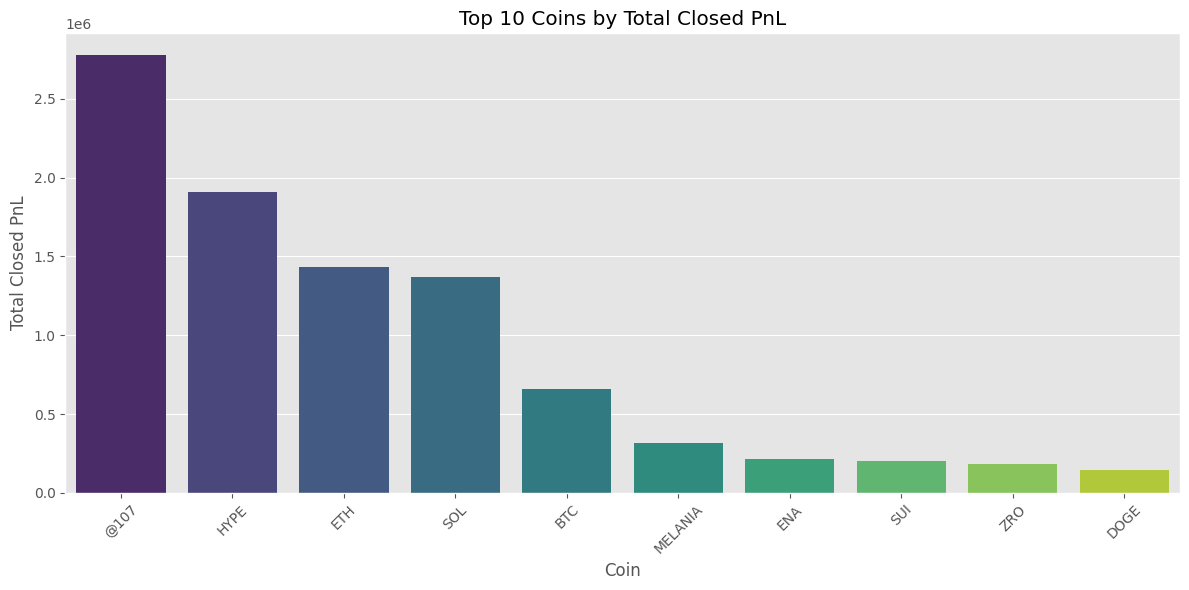

Coin
@109       270.704207
AVAX       250.026310
ENA        219.524751
@85        200.804091
EIGEN      197.063189
PEOPLE     180.323003
DOGE       178.623676
SOL        160.870153
MOODENG    153.325911
ZRO        148.327509
Name: ClosedPnL, dtype: float64


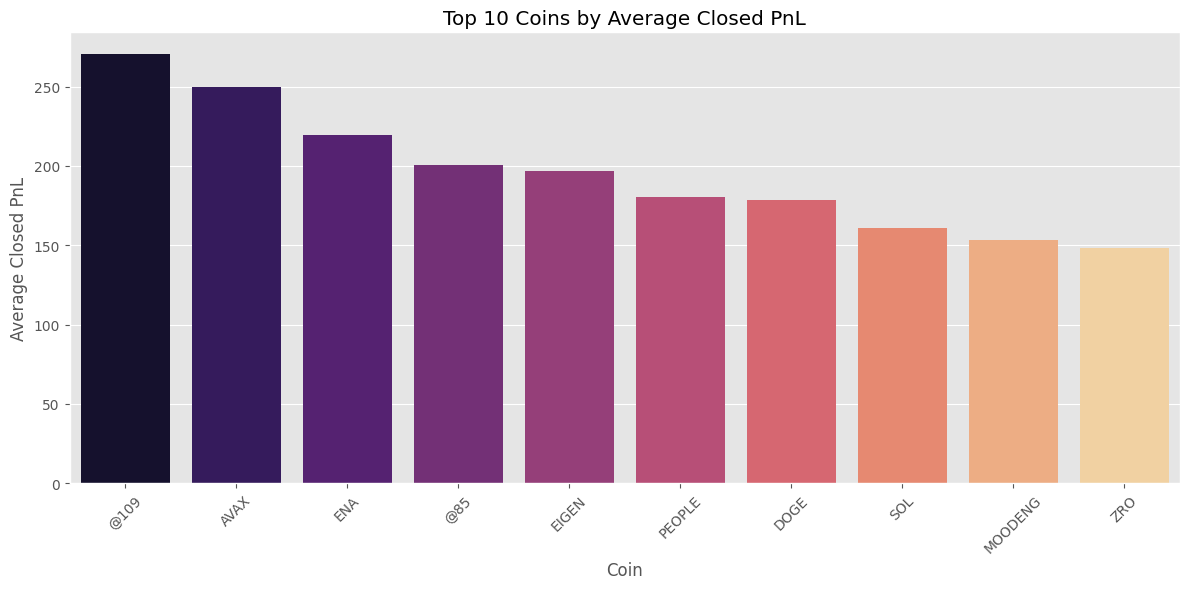

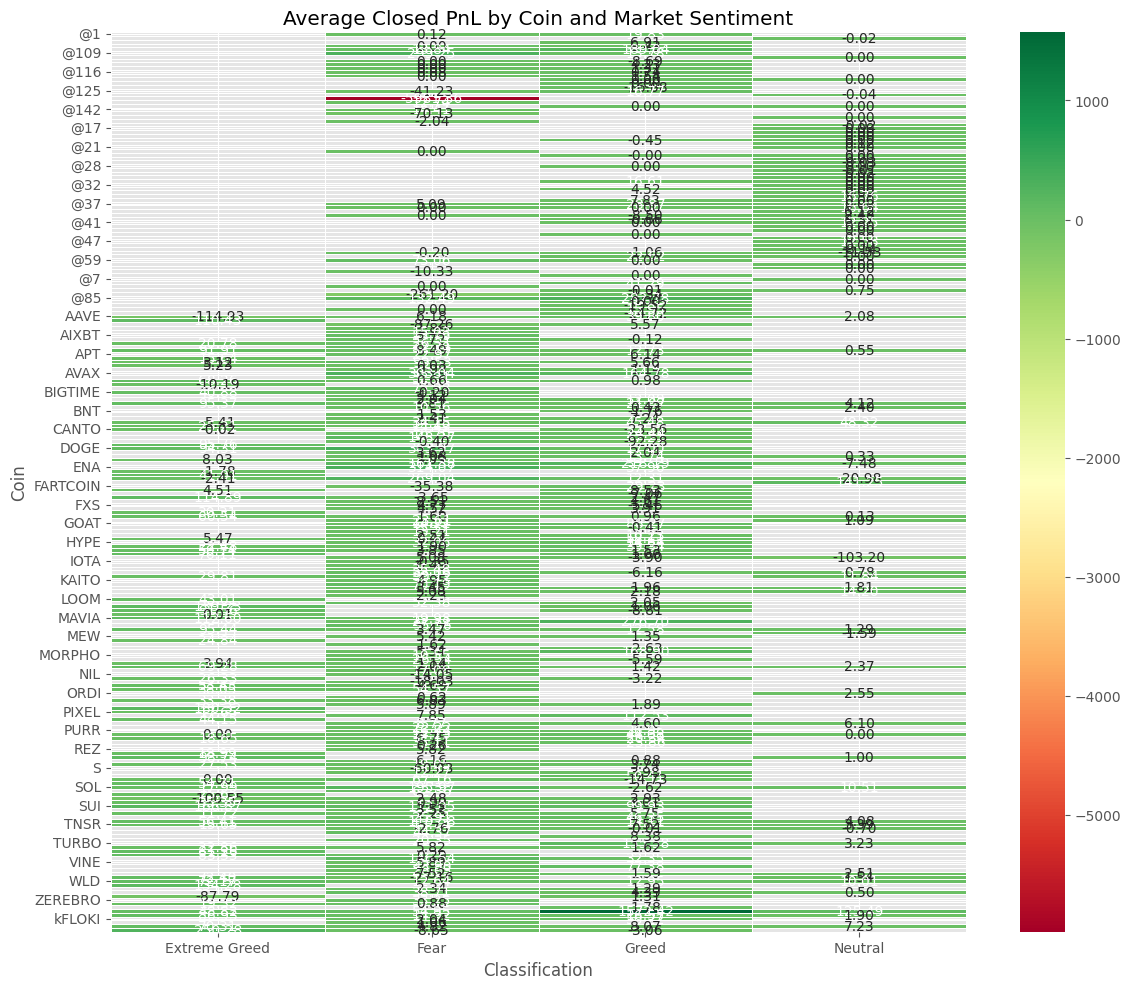

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.040922e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401572e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.111830e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.744040e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.258152e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    4.035016e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.936830e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.615766e+05
Name: ClosedPnL, dtype: float64


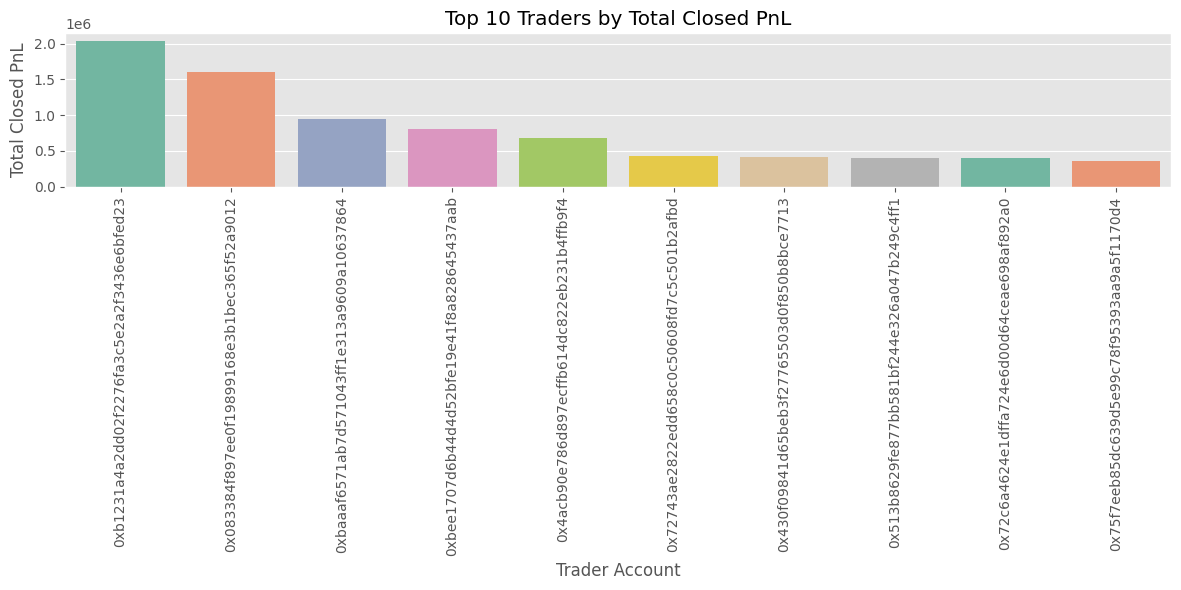

Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    36534
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21190
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14410
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    13485
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13266
0x8477e447846c758f5a675856001ea72298fd9cb5    11216
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     8948
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8340
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7479
0x513b8629fe877bb581bf244e326a047b249c4ff1     6000
Name: count, dtype: int64


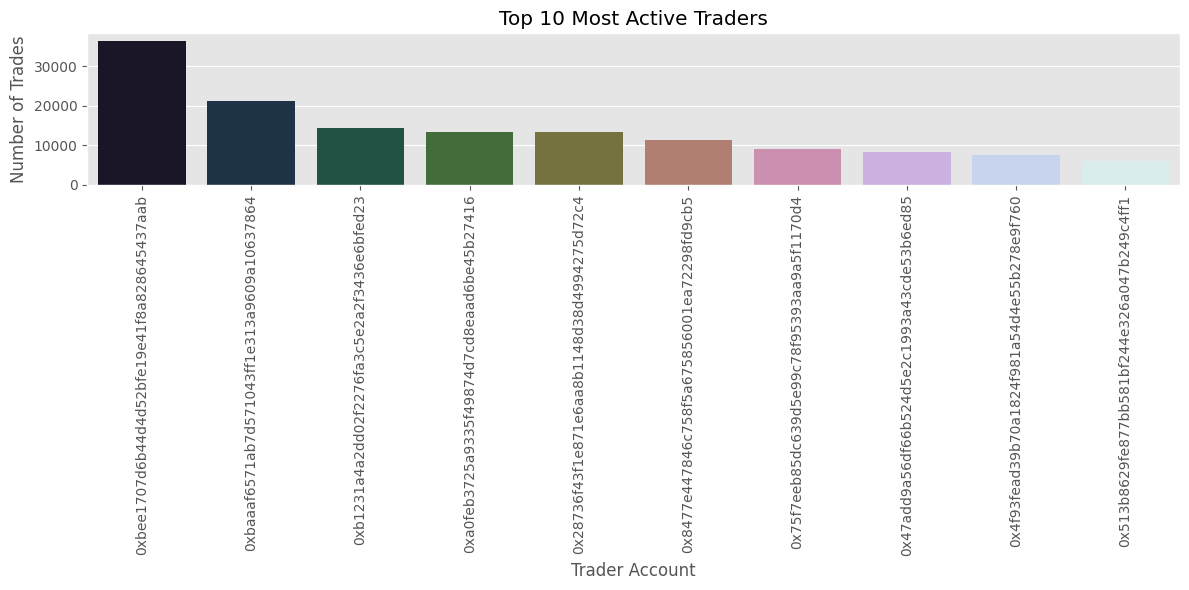

Coin
BTC         4.016258e+08
HYPE        1.328073e+08
ETH         1.150668e+08
SOL         8.694521e+07
@107        5.379083e+07
SUI         7.628904e+06
MELANIA     5.637548e+06
FARTCOIN    5.462045e+06
XRP         5.343211e+06
TRUMP       5.135719e+06
Name: TradeSizeUSD, dtype: float64


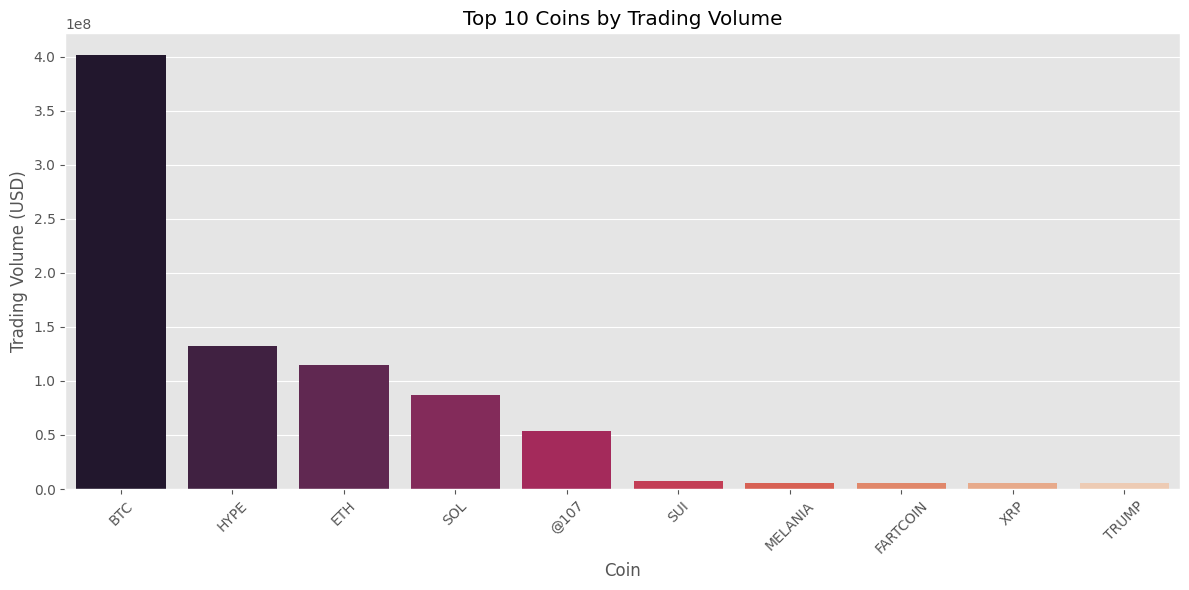

Coin
@138       100.000000
PROMPT      96.296296
POLYX       92.857143
ZETA        92.653061
ACE         92.000000
NEAR        90.454545
MINA        87.500000
ZEREBRO     87.436333
MYRO        86.666667
AR          84.615385
Name: ProfitFlag, dtype: float64


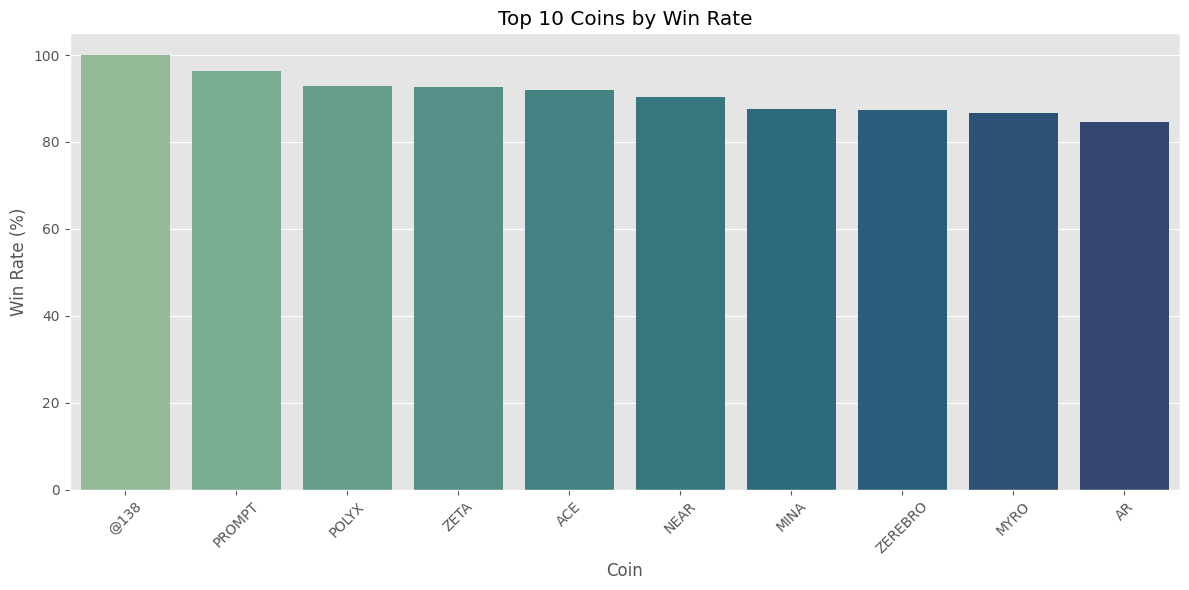

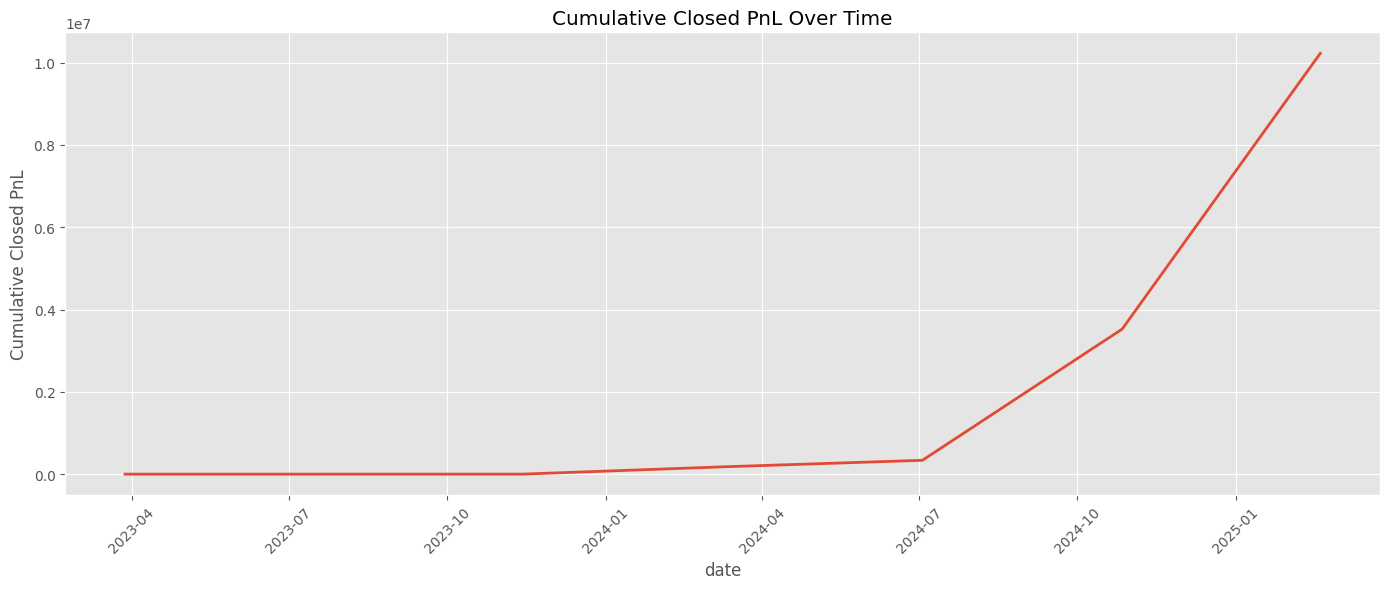

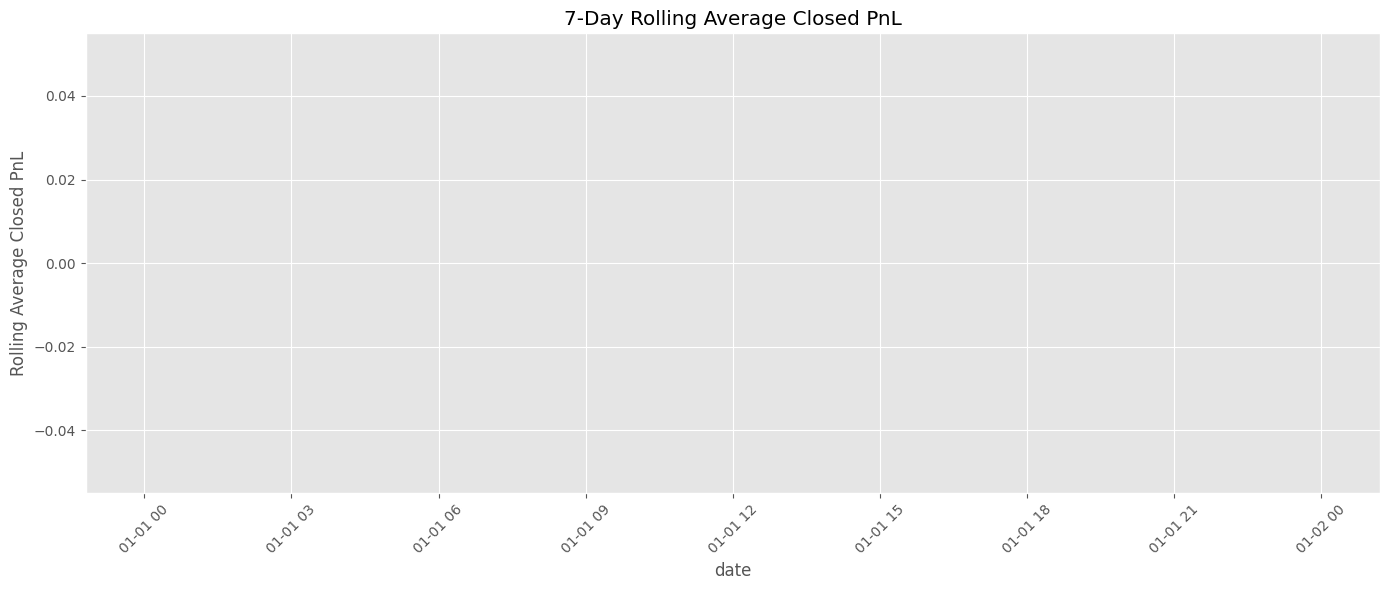

Coin
HYPE         62446
@107         27385
BTC          20135
ETH          10862
SOL           8523
FARTCOIN      3431
MELANIA       3322
PURR/USDC     2769
SUI           1847
XRP           1774
Name: count, dtype: int64


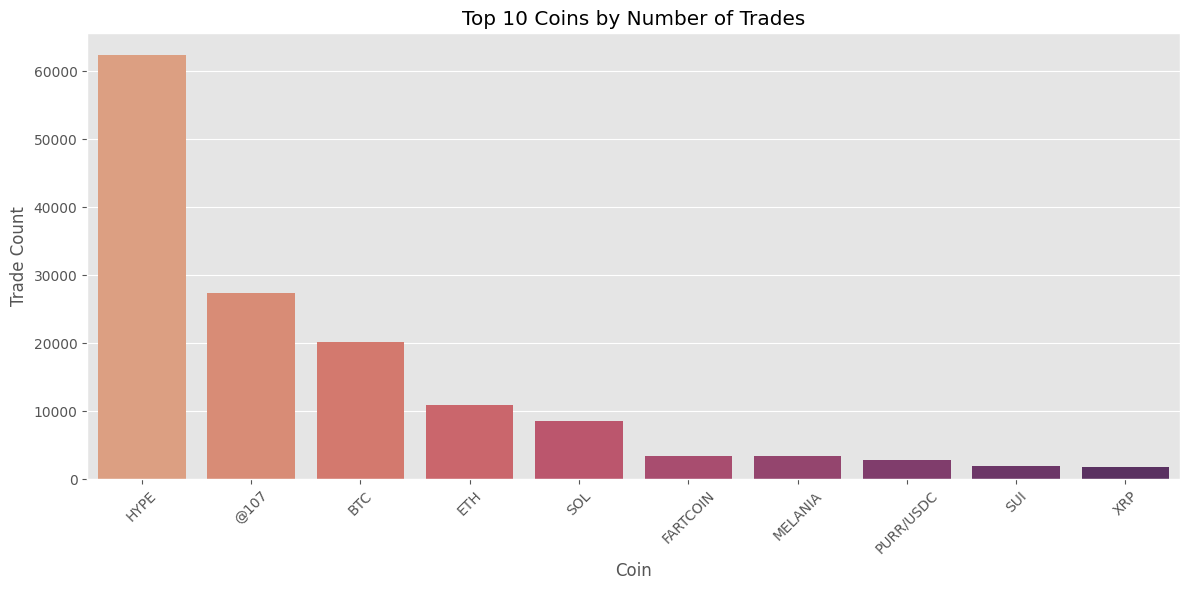


Top 10 Coins by Total Profit
Coin
@107       2.776898e+06
HYPE       1.911331e+06
ETH        1.431097e+06
SOL        1.371096e+06
BTC        6.593113e+05
MELANIA    3.168006e+05
ENA        2.173295e+05
SUI        1.986832e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: ClosedPnL, dtype: float64

Top 10 Coins by Average Profit
Coin
@109       270.704207
AVAX       250.026310
ENA        219.524751
@85        200.804091
EIGEN      197.063189
PEOPLE     180.323003
DOGE       178.623676
SOL        160.870153
MOODENG    153.325911
ZRO        148.327509
Name: ClosedPnL, dtype: float64

Top 10 Traders
Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.040922e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401572e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.111830e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.744040e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.258152e+05
0x430f09841d65beb3f2776550

In [20]:
# Top 10 Coins by Total Profit

coin_profit = merged_df.groupby('Coin')['ClosedPnL'].sum().sort_values(ascending=False).head(10)

print(coin_profit)

plt.figure(figsize=(12,6))

sns.barplot(
    x=coin_profit.index,
    y=coin_profit.values,
    palette='viridis'
)

plt.title("Top 10 Coins by Total Closed PnL")
plt.xlabel("Coin")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# Top 10 Coins by Average Profit

coin_avg_profit = merged_df.groupby('Coin')['ClosedPnL'].mean().sort_values(ascending=False).head(10)

print(coin_avg_profit)

plt.figure(figsize=(12,6))

sns.barplot(
    x=coin_avg_profit.index,
    y=coin_avg_profit.values,
    palette='magma'
)

plt.title("Top 10 Coins by Average Closed PnL")
plt.xlabel("Coin")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# Coin-wise Heatmap (Average Profit by Sentiment)

coin_heatmap = merged_df.pivot_table(
    values='ClosedPnL',
    index='Coin',
    columns='Classification',
    aggfunc='mean'
)

plt.figure(figsize=(12,10))

sns.heatmap(
    coin_heatmap,
    annot=True,
    fmt=".2f",
    cmap='RdYlGn',
    linewidths=0.5
)

plt.title("Average Closed PnL by Coin and Market Sentiment")

plt.tight_layout()

plt.show()


# Top 10 Traders by Total Profit

top_traders = merged_df.groupby('Account')['ClosedPnL'].sum().sort_values(ascending=False).head(10)

print(top_traders)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_traders.index.astype(str),
    y=top_traders.values,
    palette='Set2'
)

plt.title("Top 10 Traders by Total Closed PnL")
plt.xlabel("Trader Account")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()


# Top 10 Most Active Traders

active_traders = merged_df['Account'].value_counts().head(10)

print(active_traders)

plt.figure(figsize=(12,6))

sns.barplot(
    x=active_traders.index.astype(str),
    y=active_traders.values,
    palette='cubehelix'
)

plt.title("Top 10 Most Active Traders")
plt.xlabel("Trader Account")
plt.ylabel("Number of Trades")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()


# Top 10 Coins by Trading Volume

coin_volume = merged_df.groupby('Coin')['TradeSizeUSD'].sum().sort_values(ascending=False).head(10)

print(coin_volume)

plt.figure(figsize=(12,6))

sns.barplot(
    x=coin_volume.index,
    y=coin_volume.values,
    palette='rocket'
)

plt.title("Top 10 Coins by Trading Volume")
plt.xlabel("Coin")
plt.ylabel("Trading Volume (USD)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# Coin-wise Win Rate

coin_winrate = merged_df.groupby('Coin')['ProfitFlag'].mean() * 100
coin_winrate = coin_winrate.sort_values(ascending=False).head(10)

print(coin_winrate)

plt.figure(figsize=(12,6))

sns.barplot(
    x=coin_winrate.index,
    y=coin_winrate.values,
    palette='crest'
)

plt.title("Top 10 Coins by Win Rate")
plt.xlabel("Coin")
plt.ylabel("Win Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# Cumulative Closed PnL Over Time

daily_pnl = merged_df.groupby('TradeDate')['ClosedPnL'].sum().reset_index()

daily_pnl['CumulativePnL'] = daily_pnl['ClosedPnL'].cumsum()

plt.figure(figsize=(14,6))

plt.plot(
    daily_pnl['TradeDate'],
    daily_pnl['CumulativePnL'],
    linewidth=2
)

plt.title("Cumulative Closed PnL Over Time")
plt.xlabel("date")
plt.ylabel("Cumulative Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# Rolling Average Profit (7-Day)

daily_avg = merged_df.groupby('TradeDate')['ClosedPnL'].mean().reset_index()

daily_avg['RollingAverage'] = daily_avg['ClosedPnL'].rolling(7).mean()

plt.figure(figsize=(14,6))

plt.plot(
    daily_avg['TradeDate'],
    daily_avg['RollingAverage'],
    linewidth=2
)

plt.title("7-Day Rolling Average Closed PnL")
plt.xlabel("date")
plt.ylabel("Rolling Average Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# Top Coins by Number of Trades

coin_trades = merged_df['Coin'].value_counts().head(10)

print(coin_trades)

plt.figure(figsize=(12,6))

sns.barplot(
    x=coin_trades.index,
    y=coin_trades.values,
    palette='flare'
)

plt.title("Top 10 Coins by Number of Trades")
plt.xlabel("Coin")
plt.ylabel("Trade Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# Summary Tables

print("\nTop 10 Coins by Total Profit")
print(coin_profit)

print("\nTop 10 Coins by Average Profit")
print(coin_avg_profit)

print("\nTop 10 Traders")
print(top_traders)

print("\nMost Active Traders")
print(active_traders)

print("\nTop Coins by Trading Volume")
print(coin_volume)

print("\nCoin-wise Win Rate")
print(coin_winrate)

Part 5: Coin-wise Analysis + Trader-wise Analysis


Coin Performance Summary
          TotalTrades      TotalPnL   AveragePnL   MedianPnL     MaximumPnL  \
Coin                                                                          
@107            27385  2.776898e+06   101.402137     0.00000   44223.451870   
HYPE            62446  1.911331e+06    30.607742     0.00000   68959.002120   
ETH             10862  1.431097e+06   131.752663     0.00000  135329.090100   
SOL              8523  1.371096e+06   160.870153     0.00000   71535.716740   
BTC             20135  6.593113e+05    32.744540     0.00000   19530.522500   
...               ...           ...          ...         ...            ...   
@135                1 -5.981364e+03 -5981.363990 -5981.36399   -5981.363990   
S                 144 -8.644846e+03   -60.033651   -26.03040    2341.908910   
IO                350 -2.189673e+04   -62.562076     0.00000      80.281560   
ADA               577 -2.704846e+04   -46.877750     0.00000     669.590096   
FARTCOIN         3431 -9.6

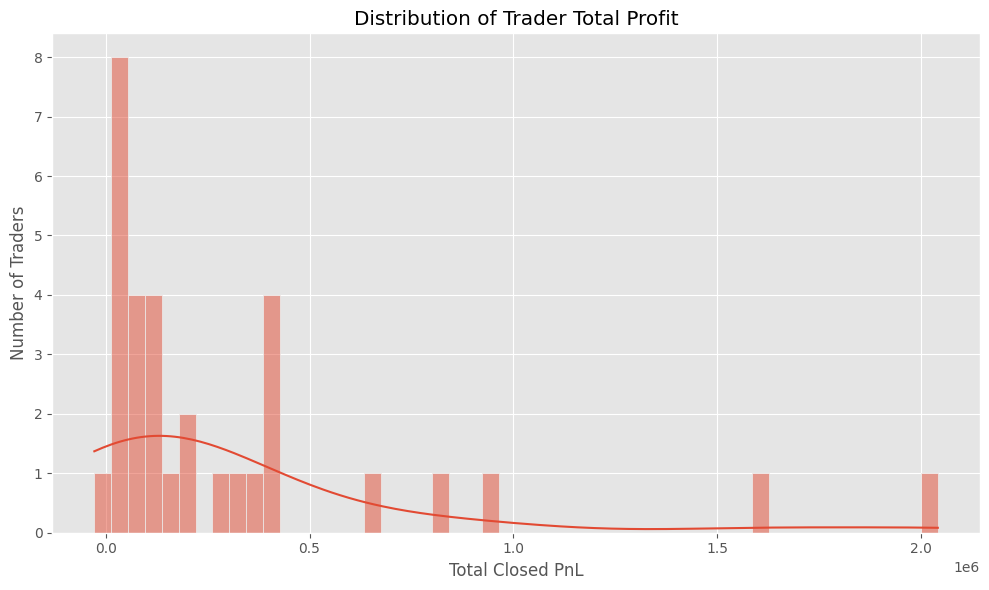

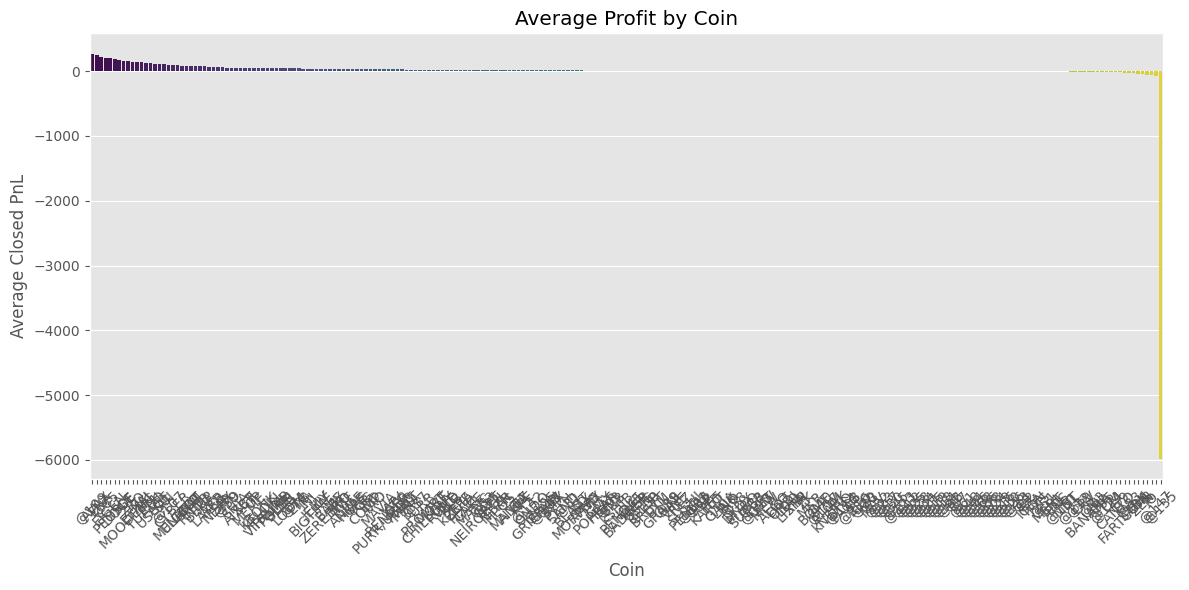

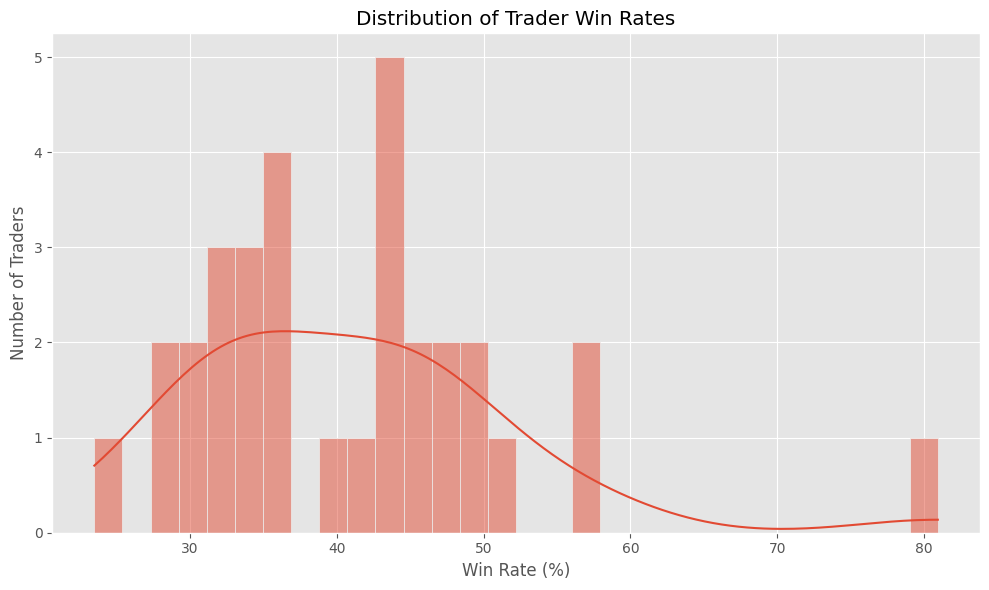

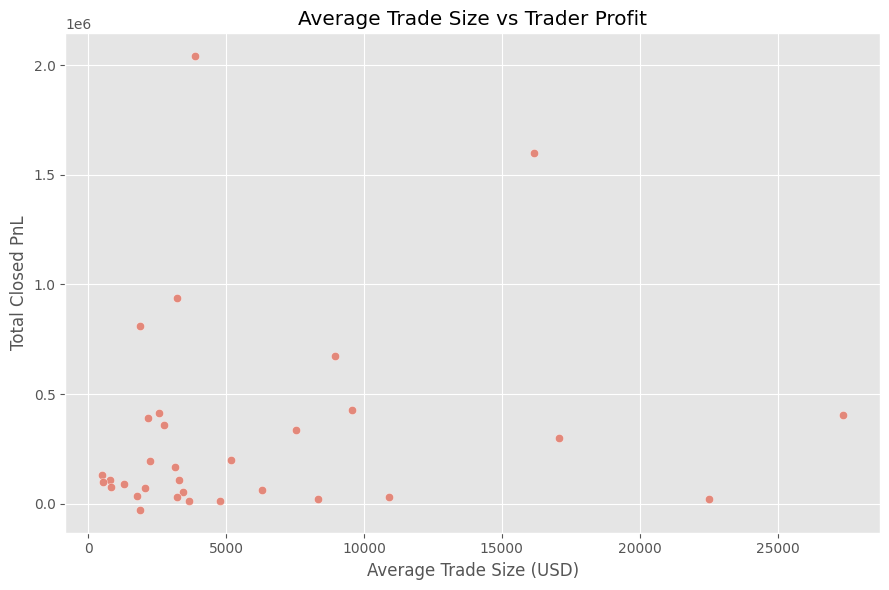


Coin-wise Sentiment Performance
Classification  Extreme Greed       Fear       Greed   Neutral
Coin                                                          
@1                        NaN   0.119853   19.826702       NaN
@10                       NaN        NaN         NaN -0.015871
@100                      NaN        NaN    6.906785       NaN
@103                      NaN   0.000000    6.426339       NaN
@107                      NaN  13.835667  189.038983       NaN
...                       ...        ...         ...       ...
kBONK               86.930889  14.917031   16.568239  1.898613
kFLOKI                    NaN   2.041975   50.216813       NaN
kNEIRO                    NaN   1.063887         NaN       NaN
kPEPE               70.311117   4.824401    8.068361  7.232333
kSHIB              250.277398  -8.647269   -3.063452       NaN

[239 rows x 4 columns]

Best Coin During Extreme Greed
Coin
kSHIB     250.277398
PEOPLE    180.323003
SUI       166.870065
MANTA     139.230689
XAI

In [21]:
# Coin-wise Performance Analysis

coin_analysis = merged_df.groupby('Coin').agg({
    'ClosedPnL':['count','sum','mean','median','max','min'],
    'TradeSizeUSD':['sum','mean'],
    'ProfitFlag':'mean',
    'Account':'nunique'
})

coin_analysis.columns = [
    'TotalTrades',
    'TotalPnL',
    'AveragePnL',
    'MedianPnL',
    'MaximumPnL',
    'MinimumPnL',
    'TotalVolumeUSD',
    'AverageTradeSize',
    'WinRate',
    'UniqueTraders'
]

coin_analysis['WinRate'] = coin_analysis['WinRate'] * 100

coin_analysis = coin_analysis.sort_values(
    by='TotalPnL',
    ascending=False
)

print("\nCoin Performance Summary")
print(coin_analysis)


# Top 10 Coins by Total Profit

print("\nTop 10 Coins by Total Profit")

print(
    coin_analysis[['TotalPnL']]
    .head(10)
)


# Top 10 Coins by Average Profit

print("\nTop 10 Coins by Average Profit")

print(
    coin_analysis[['AveragePnL']]
    .sort_values(by='AveragePnL',ascending=False)
    .head(10)
)


# Top 10 Coins by Win Rate

print("\nTop 10 Coins by Win Rate")

print(
    coin_analysis[['WinRate']]
    .sort_values(by='WinRate',ascending=False)
    .head(10)
)


# Highest Trading Volume Coins

print("\nTop Coins by Trading Volume")

print(
    coin_analysis[['TotalVolumeUSD']]
    .sort_values(by='TotalVolumeUSD',ascending=False)
    .head(10)
)


# Coins with Largest Number of Traders

print("\nCoins with Highest Participation")

print(
    coin_analysis[['UniqueTraders']]
    .sort_values(by='UniqueTraders',ascending=False)
    .head(10)
)


# Trader-wise Analysis

trader_analysis = merged_df.groupby('Account').agg({

    'ClosedPnL':['count','sum','mean','median','max','min'],

    'TradeSizeUSD':['sum','mean'],

    'ProfitFlag':'mean',

    'Coin':'nunique'

})

trader_analysis.columns = [

    'TotalTrades',

    'TotalPnL',

    'AveragePnL',

    'MedianPnL',

    'MaximumPnL',

    'MinimumPnL',

    'TotalVolumeUSD',

    'AverageTradeSize',

    'WinRate',

    'UniqueCoins'

]

trader_analysis['WinRate'] = trader_analysis['WinRate'] * 100

trader_analysis = trader_analysis.sort_values(
    by='TotalPnL',
    ascending=False
)

print("\nTrader Performance Summary")

print(trader_analysis)


# Top 10 Traders

print("\nTop 10 Traders by Total Profit")

print(
    trader_analysis.head(10)
)


# Top 10 Traders by Win Rate

print("\nTop 10 Traders by Win Rate")

print(
    trader_analysis
    .sort_values(by='WinRate',ascending=False)
    .head(10)
)


# Most Active Traders

print("\nMost Active Traders")

print(
    trader_analysis
    .sort_values(by='TotalTrades',ascending=False)
    .head(10)
)


# Traders Handling Highest Trading Volume

print("\nHighest Trading Volume Traders")

print(
    trader_analysis
    .sort_values(by='TotalVolumeUSD',ascending=False)
    .head(10)
)


# Traders Trading Multiple Coins

print("\nMost Diversified Traders")

print(
    trader_analysis
    .sort_values(by='UniqueCoins',ascending=False)
    .head(10)
)


# Trader Profit Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    trader_analysis['TotalPnL'],
    bins=50,
    kde=True
)

plt.title("Distribution of Trader Total Profit")

plt.xlabel("Total Closed PnL")

plt.ylabel("Number of Traders")

plt.tight_layout()

plt.show()


# Average Profit per Coin

coin_profit = merged_df.groupby('Coin')['ClosedPnL'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=coin_profit.index,
    y=coin_profit.values,
    palette='viridis'
)

plt.title("Average Profit by Coin")

plt.xlabel("Coin")

plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# Trader Win Rate Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    trader_analysis['WinRate'],
    bins=30,
    kde=True
)

plt.title("Distribution of Trader Win Rates")

plt.xlabel("Win Rate (%)")

plt.ylabel("Number of Traders")

plt.tight_layout()

plt.show()


# Scatter Plot: Average Trade Size vs Total Profit

plt.figure(figsize=(9,6))

sns.scatterplot(

    data=trader_analysis,

    x='AverageTradeSize',

    y='TotalPnL',

    alpha=0.6

)

plt.title("Average Trade Size vs Trader Profit")

plt.xlabel("Average Trade Size (USD)")

plt.ylabel("Total Closed PnL")

plt.tight_layout()

plt.show()


# Coin-wise Sentiment Analysis

coin_sentiment = merged_df.pivot_table(

    index='Coin',

    columns='Classification',

    values='ClosedPnL',

    aggfunc='mean'

)

print("\nCoin-wise Sentiment Performance")

print(coin_sentiment)


# Best Coin Under Each Sentiment

for sentiment in coin_sentiment.columns:

    print("\nBest Coin During", sentiment)

    print(
        coin_sentiment[sentiment]
        .sort_values(ascending=False)
        .head(5)
    )


# Trader Ranking Score

trader_analysis['PerformanceScore'] = (

    trader_analysis['TotalPnL'] * 0.50 +

    trader_analysis['WinRate'] * 5 +

    trader_analysis['UniqueCoins'] * 2

)

print("\nTop Traders by Performance Score")

print(

    trader_analysis

    .sort_values(

        by='PerformanceScore',

        ascending=False

    )

    .head(10)

)


# Save Results

coin_analysis.to_csv(
    "coin_analysis.csv"
)

trader_analysis.to_csv(
    "trader_analysis.csv"
)

print("\nCoin-wise and Trader-wise analysis completed successfully.")

Part 6: Long/Short Analysis, Trade Size Analysis, Daily & Monthly Trend Analysis

                      TotalTrades      TotalPnL   AveragePnL    MedianPnL  \
Direction                                                                   
Auto-Deleveraging               8  5.747846e+04  7184.807003  5237.985558   
Buy                         14657  0.000000e+00     0.000000     0.000000   
Close Long                  44935  3.109117e+06    69.191429     6.708000   
Close Short                 28091  4.159133e+06   148.059254     6.793628   
Long > Short                   54  1.963565e+03    36.362308     0.114993   
Open Long                   45564  0.000000e+00     0.000000     0.000000   
Open Short                  32861  0.000000e+00     0.000000     0.000000   
Sell                        17890  2.885395e+06   161.285380     7.522560   
Settlement                      1 -2.921537e+01   -29.215368   -29.215368   
Short > Long                   65  1.219196e+04   187.568677    14.080630   
Spot Dust Conversion          137  0.000000e+00     0.000000     0.000000   

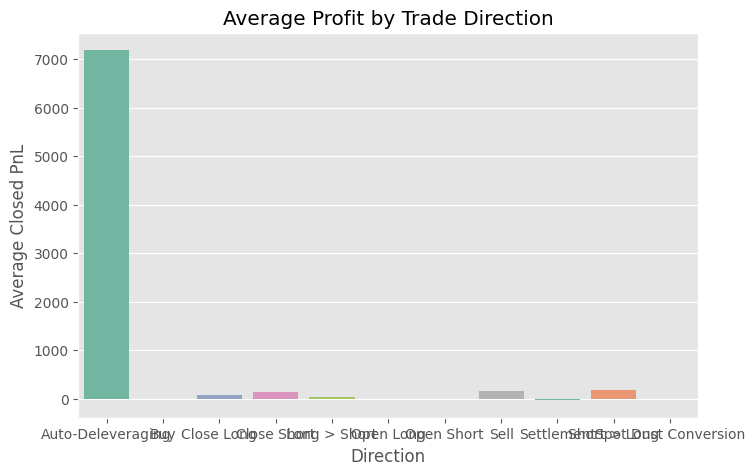

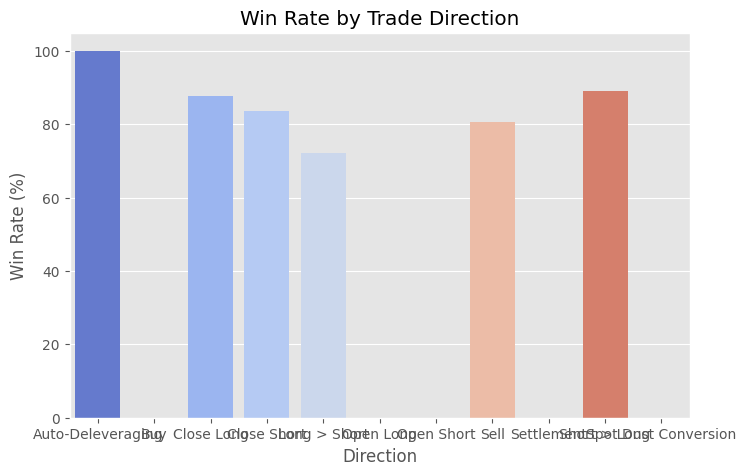

count    1.842630e+05
mean     4.780733e+03
std      2.690428e+04
min      0.000000e+00
25%      1.875300e+02
50%      5.927400e+02
75%      2.032705e+03
max      3.509753e+06
Name: TradeSizeUSD, dtype: float64
                   Trades  AveragePnL      TotalPnL    WinRate
TradeSizeCategory                                             
Small               46806    2.397700  1.122267e+05  43.633295
Medium              45740    8.006918  3.662364e+05  40.268911
Large               46457   24.135054  1.121242e+06  43.489679
Very Large          45260  190.577646  8.625544e+06  40.673884


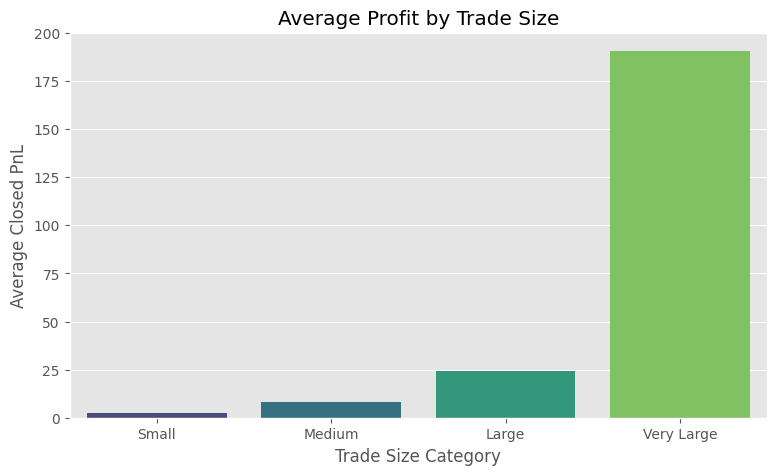

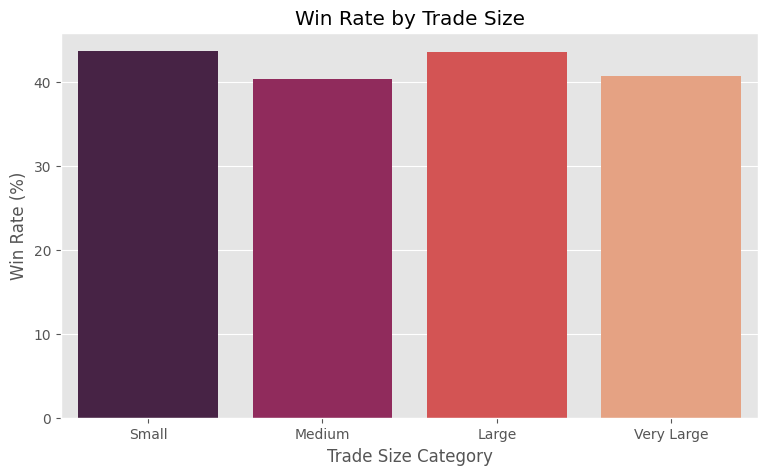

   Hour  ClosedPnL  TradeSizeUSD
0     3  90.504272  1.039478e+08
1     9  22.229713  2.184323e+07
2    10   0.000000  4.770000e+02
3    16  25.418772  3.940677e+07
4    21  50.047622  7.041585e+08
5    22   0.148807  1.155543e+07


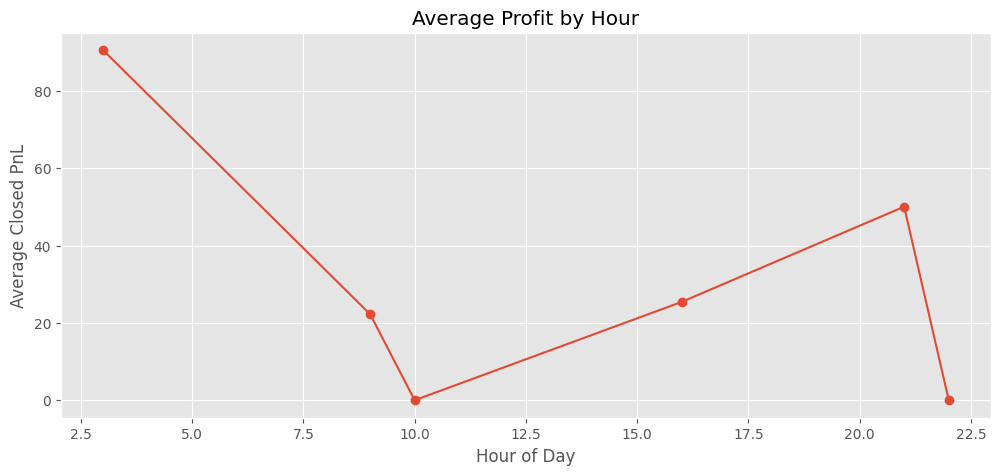

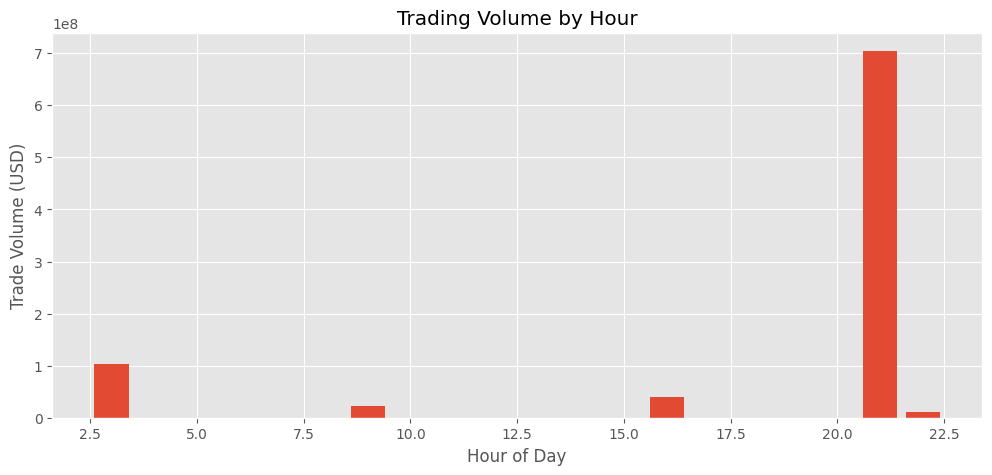

   TradeDate      TotalPnL  AveragePnL   TotalVolume    WinRate
0 2023-03-28  0.000000e+00    0.000000  4.770000e+02   0.000000
1 2023-11-14  1.555034e+02    0.148807  1.155543e+07  27.464115
2 2024-03-09  1.769655e+05   25.418772  3.940677e+07  49.008905
3 2024-07-03  1.587424e+05   22.229713  2.184323e+07  31.718247
4 2024-10-27  3.189461e+06   90.504272  1.039478e+08  45.160467


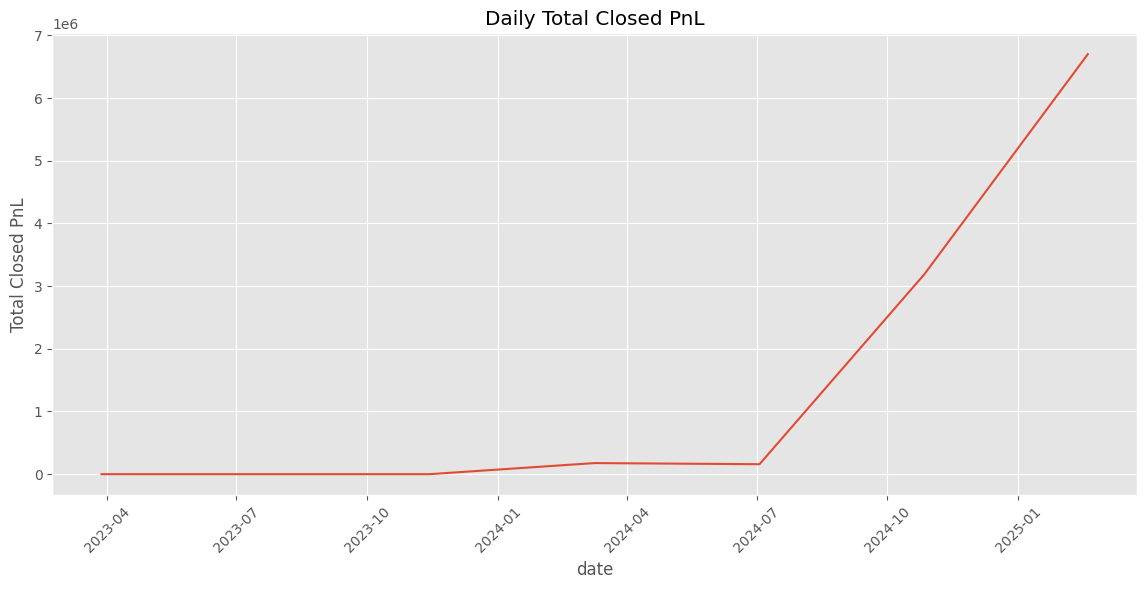

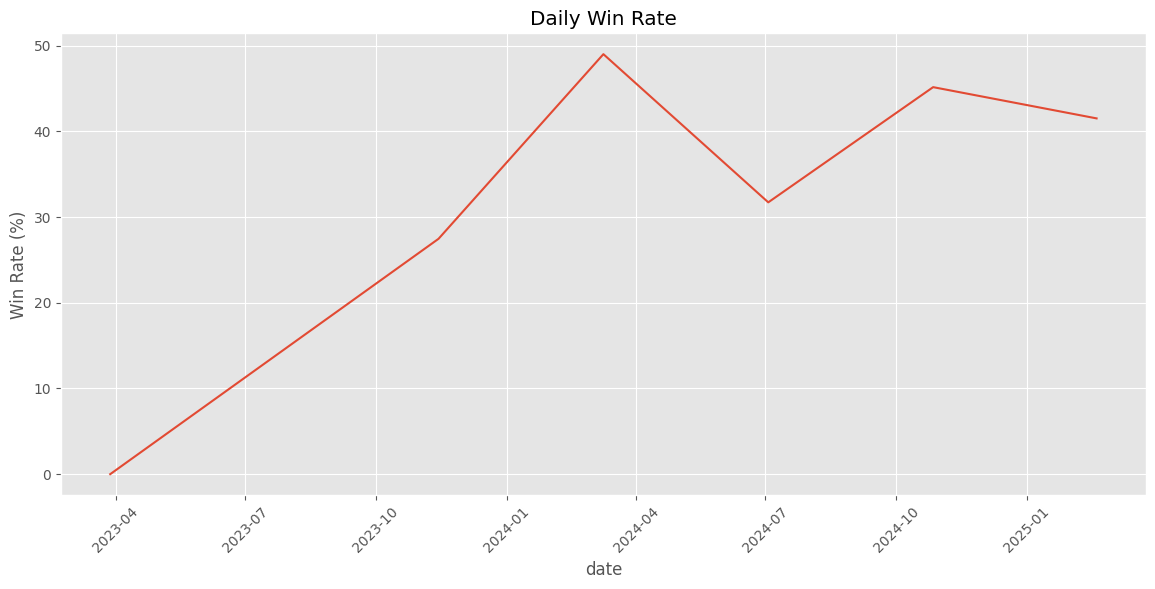

   Year MonthName      TotalPnL  AveragePnL   TradeVolume    WinRate
0  2023     March  0.000000e+00    0.000000  4.770000e+02   0.000000
1  2023  November  1.555034e+02    0.148807  1.155543e+07  27.464115
2  2024      July  1.587424e+05   22.229713  2.184323e+07  31.718247
3  2024     March  1.769655e+05   25.418772  3.940677e+07  49.008905
4  2024   October  3.189461e+06   90.504272  1.039478e+08  45.160467
5  2025  February  6.699925e+06   50.047622  7.041585e+08  41.514592


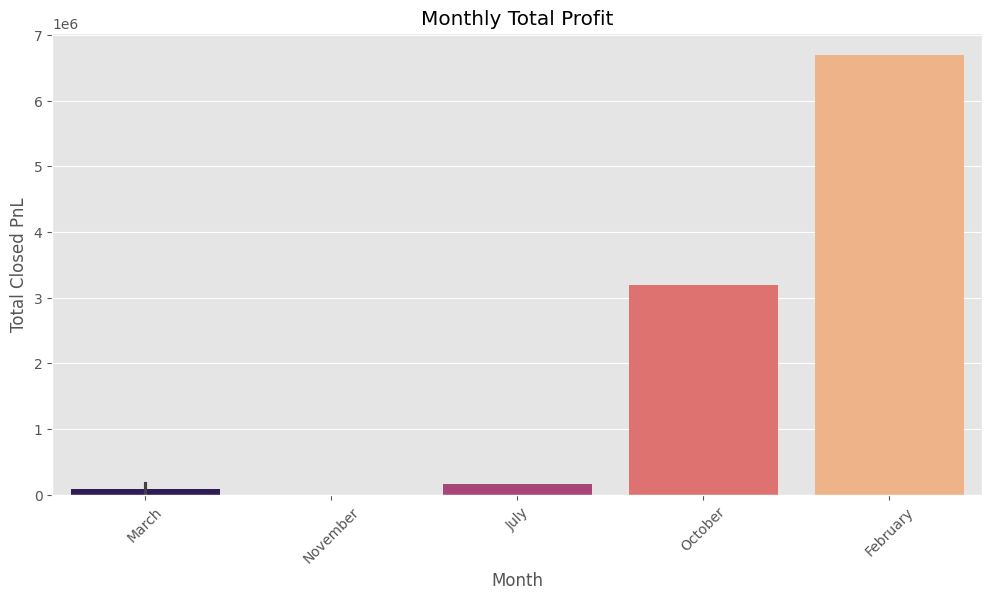

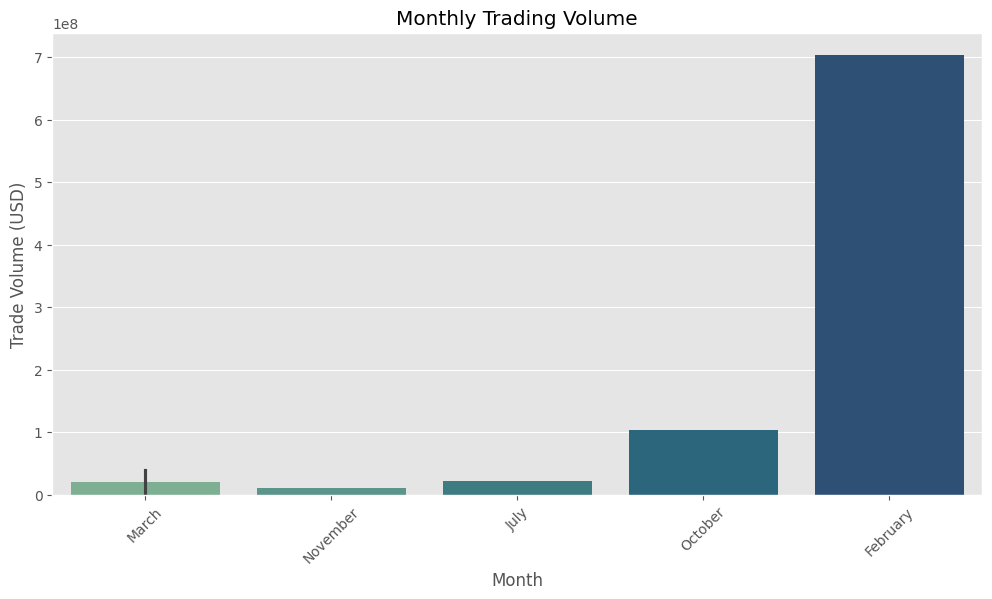

Classification  Extreme Greed       Fear      Greed    Neutral
MonthName                                                     
February                  NaN  50.047622        NaN        NaN
July                      NaN        NaN        NaN  22.229713
March               25.418772        NaN   0.000000        NaN
November                  NaN        NaN   0.148807        NaN
October                   NaN        NaN  90.504272        NaN


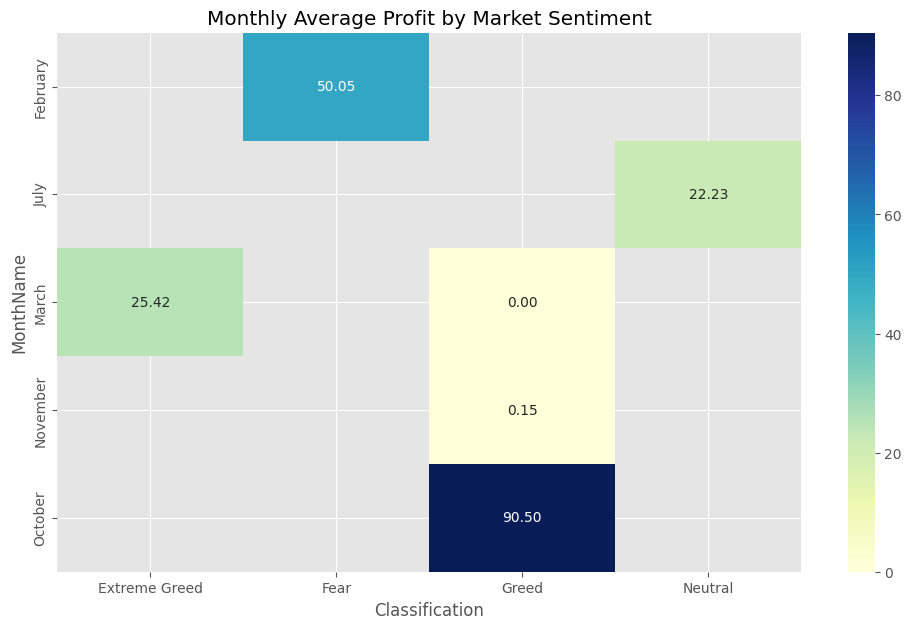


Best Trading Hour
Hour            3.000000e+00
ClosedPnL       9.050427e+01
TradeSizeUSD    1.039478e+08
Name: 0, dtype: float64

Best Trading Month
Year                     2025
MonthName            February
TotalPnL       6699925.190574
AveragePnL          50.047622
TradeVolume      704158492.98
WinRate             41.514592
Name: 5, dtype: object

Direction Analysis
                      TotalTrades      TotalPnL   AveragePnL    MedianPnL  \
Direction                                                                   
Auto-Deleveraging               8  5.747846e+04  7184.807003  5237.985558   
Buy                         14657  0.000000e+00     0.000000     0.000000   
Close Long                  44935  3.109117e+06    69.191429     6.708000   
Close Short                 28091  4.159133e+06   148.059254     6.793628   
Long > Short                   54  1.963565e+03    36.362308     0.114993   
Open Long                   45564  0.000000e+00     0.000000     0.000000   
Open Short 

In [22]:
# Long vs Short Performance

direction_analysis = merged_df.groupby('Direction').agg({
    'ClosedPnL':['count','sum','mean','median','max','min'],
    'TradeSizeUSD':['sum','mean'],
    'ProfitFlag':'mean'
})

direction_analysis.columns = [
    'TotalTrades',
    'TotalPnL',
    'AveragePnL',
    'MedianPnL',
    'MaximumPnL',
    'MinimumPnL',
    'TotalTradeVolume',
    'AverageTradeSize',
    'WinRate'
]

direction_analysis['WinRate'] *= 100

print(direction_analysis)


# Long vs Short Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=direction_analysis.reset_index(),
    x='Direction',
    y='AveragePnL',
    palette='Set2'
)

plt.title("Average Profit by Trade Direction")
plt.xlabel("Direction")
plt.ylabel("Average Closed PnL")

plt.show()


# Win Rate by Direction

plt.figure(figsize=(8,5))

sns.barplot(
    data=direction_analysis.reset_index(),
    x='Direction',
    y='WinRate',
    palette='coolwarm'
)

plt.title("Win Rate by Trade Direction")
plt.xlabel("Direction")
plt.ylabel("Win Rate (%)")

plt.show()


# Trade Size Statistics

trade_size_stats = merged_df['TradeSizeUSD'].describe()

print(trade_size_stats)


# Trade Size Categories

trade_size_summary = merged_df.groupby(
    'TradeSizeCategory'
).agg({

    'ClosedPnL':['count','mean','sum'],

    'ProfitFlag':'mean'

})

trade_size_summary.columns = [

    'Trades',

    'AveragePnL',

    'TotalPnL',

    'WinRate'

]

trade_size_summary['WinRate'] *= 100

print(trade_size_summary)


# Profit by Trade Size

plt.figure(figsize=(9,5))

sns.barplot(

    data=trade_size_summary.reset_index(),

    x='TradeSizeCategory',

    y='AveragePnL',

    palette='viridis'

)

plt.title("Average Profit by Trade Size")

plt.xlabel("Trade Size Category")

plt.ylabel("Average Closed PnL")

plt.show()


# Win Rate by Trade Size

plt.figure(figsize=(9,5))

sns.barplot(

    data=trade_size_summary.reset_index(),

    x='TradeSizeCategory',

    y='WinRate',

    palette='rocket'

)

plt.title("Win Rate by Trade Size")

plt.xlabel("Trade Size Category")

plt.ylabel("Win Rate (%)")

plt.show()


# Hourly Trading Activity

hourly_analysis = merged_df.groupby('Hour').agg({

    'ClosedPnL':'mean',

    'TradeSizeUSD':'sum'

}).reset_index()

print(hourly_analysis)


plt.figure(figsize=(12,5))

plt.plot(

    hourly_analysis['Hour'],

    hourly_analysis['ClosedPnL'],

    marker='o'

)

plt.title("Average Profit by Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Average Closed PnL")

plt.grid(True)

plt.show()


# Hourly Trading Volume

plt.figure(figsize=(12,5))

plt.bar(

    hourly_analysis['Hour'],

    hourly_analysis['TradeSizeUSD']

)

plt.title("Trading Volume by Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Trade Volume (USD)")

plt.show()


# Daily Performance

daily_analysis = merged_df.groupby('TradeDate').agg({

    'ClosedPnL':['sum','mean'],

    'TradeSizeUSD':'sum',

    'ProfitFlag':'mean'

})

daily_analysis.columns = [

    'TotalPnL',

    'AveragePnL',

    'TotalVolume',

    'WinRate'

]

daily_analysis['WinRate'] *= 100

daily_analysis.reset_index(inplace=True)

print(daily_analysis.head())


# Daily Total Profit

plt.figure(figsize=(14,6))

plt.plot(

    daily_analysis['TradeDate'],

    daily_analysis['TotalPnL']

)

plt.title("Daily Total Closed PnL")

plt.xlabel("date")

plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.show()


# Daily Win Rate

plt.figure(figsize=(14,6))

plt.plot(

    daily_analysis['TradeDate'],

    daily_analysis['WinRate']

)

plt.title("Daily Win Rate")

plt.xlabel("date")

plt.ylabel("Win Rate (%)")

plt.xticks(rotation=45)

plt.show()


# Monthly Performance

monthly_analysis = merged_df.groupby(

    ['Year','MonthName']

).agg({

    'ClosedPnL':['sum','mean'],

    'TradeSizeUSD':'sum',

    'ProfitFlag':'mean'

})

monthly_analysis.columns = [

    'TotalPnL',

    'AveragePnL',

    'TradeVolume',

    'WinRate'

]

monthly_analysis['WinRate'] *= 100

monthly_analysis.reset_index(inplace=True)

print(monthly_analysis)


# Monthly Total Profit

plt.figure(figsize=(12,6))

sns.barplot(

    data=monthly_analysis,

    x='MonthName',

    y='TotalPnL',

    palette='magma'

)

plt.title("Monthly Total Profit")

plt.xlabel("Month")

plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.show()


# Monthly Trading Volume

plt.figure(figsize=(12,6))

sns.barplot(

    data=monthly_analysis,

    x='MonthName',

    y='TradeVolume',

    palette='crest'

)

plt.title("Monthly Trading Volume")

plt.xlabel("Month")

plt.ylabel("Trade Volume (USD)")

plt.xticks(rotation=45)

plt.show()


# Sentiment-wise Monthly Profit

monthly_sentiment = merged_df.pivot_table(

    values='ClosedPnL',

    index='MonthName',

    columns='Classification',

    aggfunc='mean'

)

print(monthly_sentiment)


plt.figure(figsize=(12,7))

sns.heatmap(

    monthly_sentiment,

    annot=True,

    fmt=".2f",

    cmap="YlGnBu"

)

plt.title("Monthly Average Profit by Market Sentiment")

plt.show()


# Best Trading Hour

best_hour = hourly_analysis.loc[
    hourly_analysis['ClosedPnL'].idxmax()
]

print("\nBest Trading Hour")

print(best_hour)


# Best Trading Month

best_month = monthly_analysis.loc[
    monthly_analysis['TotalPnL'].idxmax()
]

print("\nBest Trading Month")

print(best_month)


# Summary

print("\nDirection Analysis")

print(direction_analysis)

print("\nTrade Size Analysis")

print(trade_size_summary)

print("\nDaily Analysis")

print(daily_analysis.describe())

print("\nMonthly Analysis")

print(monthly_analysis.describe())

Part 7: Correlation Matrix & Hypothesis Testing


Correlation Matrix
                  ExecutionPrice  TradeSizeUSD  ClosedPnL  AbsolutePnL  \
ExecutionPrice          1.000000      0.194472  -0.007894    -0.005319   
TradeSizeUSD            0.194472      1.000000   0.136853     0.245651   
ClosedPnL              -0.007894      0.136853   1.000000     0.664101   
AbsolutePnL            -0.005319      0.245651   0.664101     1.000000   
ProfitFlag             -0.051760     -0.001553   0.094155     0.073541   
DirectionEncoded        0.020352     -0.011704  -0.011058    -0.019652   

                  ProfitFlag  DirectionEncoded  
ExecutionPrice     -0.051760          0.020352  
TradeSizeUSD       -0.001553         -0.011704  
ClosedPnL           0.094155         -0.011058  
AbsolutePnL         0.073541         -0.019652  
ProfitFlag          1.000000         -0.397480  
DirectionEncoded   -0.397480          1.000000  


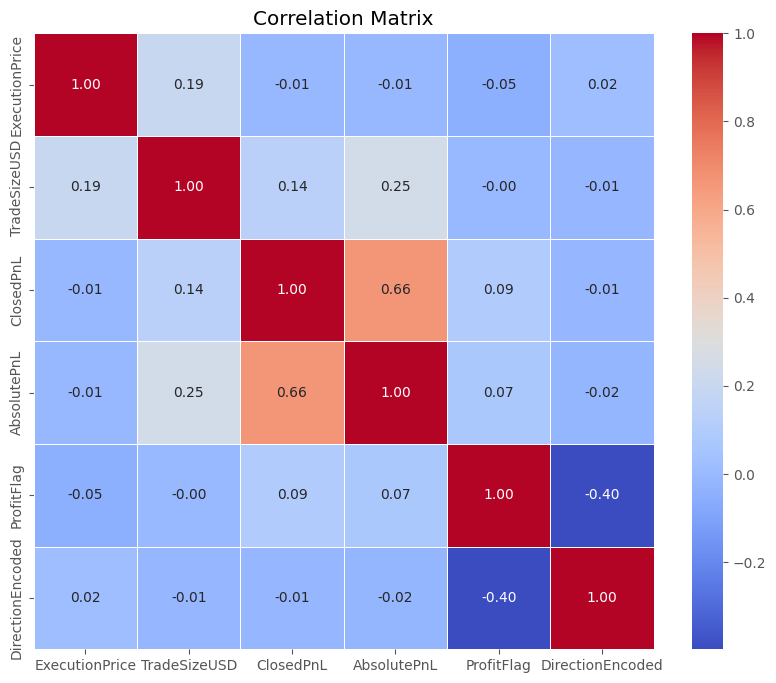


Pearson Correlation
Correlation : 0.13685286172677807
P-value : 0.0

Spearman Correlation
Correlation : 0.11504389216691155
P-value : 0.0

Independent T-Test
T Statistic : -4.9038309651960725
P Value : 9.421142077044365e-07
Result : Reject Null Hypothesis

ANOVA Test
F_onewayResult(statistic=np.float64(21.33042041351865), pvalue=np.float64(8.287959255248323e-14))
Significant difference exists among sentiment groups.

Shapiro-Wilk Test
Statistic : 0.03455814409874747
P-value : 5.071827154350211e-95
Data is NOT normally distributed.

Contingency Table
TradeCategory    Loss  Profit
Classification               
Extreme Greed    3550    3412
Fear            78295   55576
Greed           20087   16202
Neutral          4876    2265

Chi-Square Test
Chi2 : 567.4065044816895
P-value : 1.171908380060481e-122
Degrees of Freedom : 3
Trade outcome depends on market sentiment.

Profit Statistics by Sentiment
                   count       mean          std           min  25%  50%  \
Classification

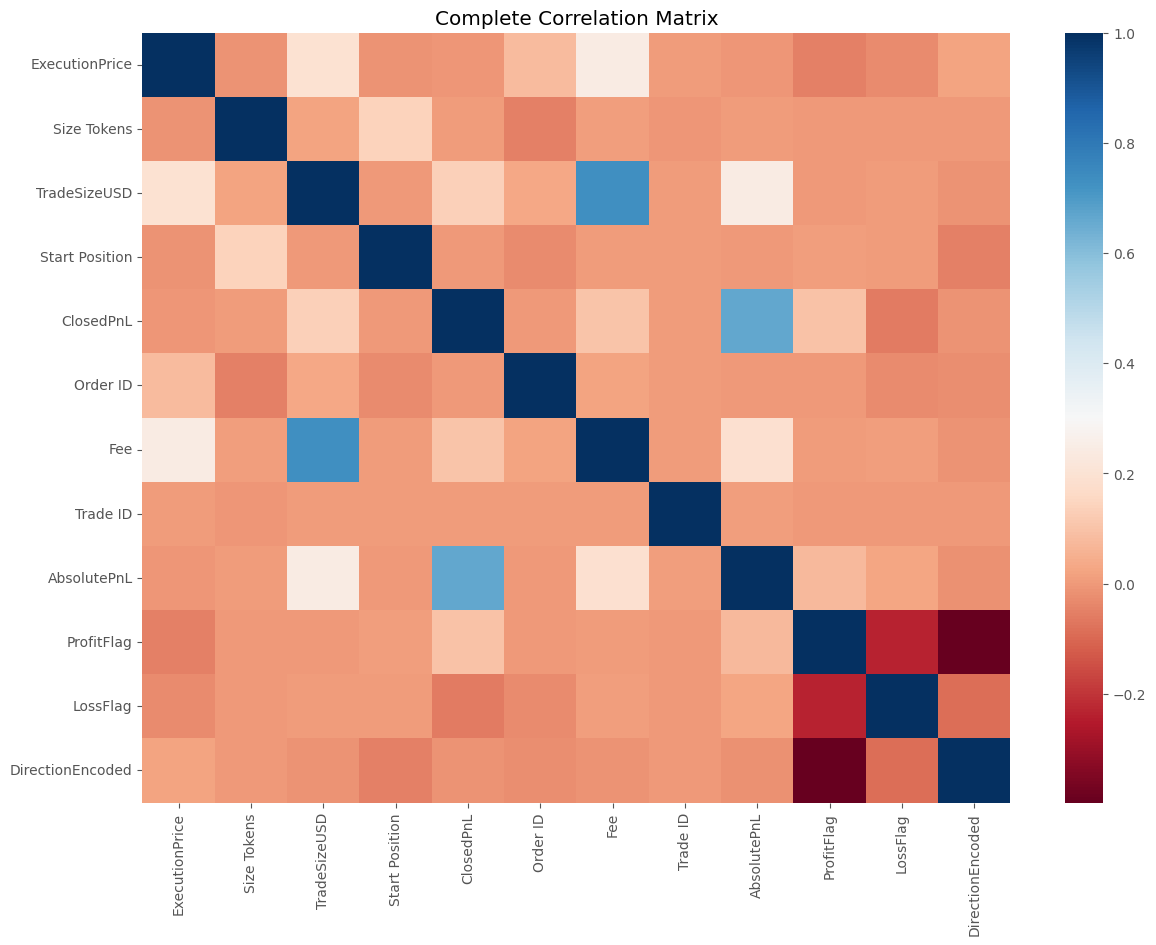


Correlation with ClosedPnL
ClosedPnL           1.000000
AbsolutePnL         0.664101
TradeSizeUSD        0.136853
Fee                 0.103585
ProfitFlag          0.094155
Size Tokens         0.005037
Trade ID            0.002994
Order ID            0.000218
Start Position      0.000165
ExecutionPrice     -0.007894
DirectionEncoded   -0.011058
LossFlag           -0.063563
Name: ClosedPnL, dtype: float64

Statistical Summary
       ExecutionPrice   Size Tokens  TradeSizeUSD  Start Position  \
count   184263.000000  1.842630e+05  1.842630e+05    1.842630e+05   
mean      9624.179560  4.588772e+03  4.780733e+03    1.634172e+04   
std      27106.266497  1.105144e+05  2.690428e+04    3.938825e+05   
min          0.000005  8.740000e-07  0.000000e+00   -1.433463e+07   
25%          5.024600  3.650000e+00  1.875300e+02   -1.189096e+02   
50%         17.770000  3.400000e+01  5.927400e+02    3.701700e+02   
75%         28.920000  1.803000e+02  2.032705e+03    1.264308e+04   
max     109004.0000

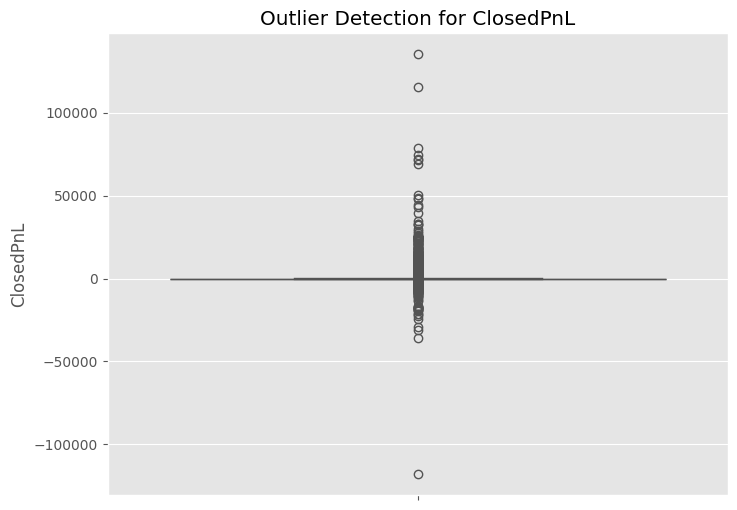


Interpretation
1. Pearson correlation measures linear relationship.
2. Spearman correlation measures monotonic relationship.
3. T-test compares Fear and Greed profitability.
4. ANOVA compares profitability across all sentiment groups.
5. Chi-Square checks dependence between sentiment and trade outcome.
6. Shapiro-Wilk evaluates normality.
7. Correlation matrix identifies relationships among numerical variables.
8. Outlier detection highlights extreme profit/loss trades.


In [23]:
from scipy.stats import (
    ttest_ind,
    f_oneway,
    pearsonr,
    spearmanr,
    shapiro,
    chi2_contingency
)

# Correlation Matrix

correlation_columns = [
    'ExecutionPrice',
    'TradeSizeUSD',
    'ClosedPnL',
    'AbsolutePnL',
    'ProfitFlag',
    'DirectionEncoded'
]

corr_matrix = merged_df[correlation_columns].corr()

print("\nCorrelation Matrix")
print(corr_matrix)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()


# Pearson Correlation

pearson_corr, pearson_p = pearsonr(
    merged_df['TradeSizeUSD'],
    merged_df['ClosedPnL']
)

print("\nPearson Correlation")

print("Correlation :", pearson_corr)

print("P-value :", pearson_p)


# Spearman Correlation

spearman_corr, spearman_p = spearmanr(
    merged_df['TradeSizeUSD'],
    merged_df['ClosedPnL']
)

print("\nSpearman Correlation")

print("Correlation :", spearman_corr)

print("P-value :", spearman_p)


# Fear vs Greed T-Test

fear_profit = merged_df[
    merged_df['Classification'].str.contains("Fear")
]['ClosedPnL']

greed_profit = merged_df[
    merged_df['Classification'].str.contains("Greed")
]['ClosedPnL']

t_stat, p_value = ttest_ind(
    fear_profit,
    greed_profit,
    equal_var=False
)

print("\nIndependent T-Test")

print("T Statistic :", t_stat)

print("P Value :", p_value)

if p_value < 0.05:
    print("Result : Reject Null Hypothesis")
else:
    print("Result : Fail to Reject Null Hypothesis")


# ANOVA Test

anova_groups = []

for sentiment in merged_df['Classification'].unique():

    values = merged_df[
        merged_df['Classification'] == sentiment
    ]['ClosedPnL']

    anova_groups.append(values)

anova_result = f_oneway(*anova_groups)

print("\nANOVA Test")

print(anova_result)

if anova_result.pvalue < 0.05:
    print("Significant difference exists among sentiment groups.")
else:
    print("No significant difference among sentiment groups.")


# Normality Test

sample_profit = merged_df['ClosedPnL'].sample(
    min(5000, len(merged_df)),
    random_state=42
)

shapiro_stat, shapiro_p = shapiro(sample_profit)

print("\nShapiro-Wilk Test")

print("Statistic :", shapiro_stat)

print("P-value :", shapiro_p)

if shapiro_p < 0.05:
    print("Data is NOT normally distributed.")
else:
    print("Data follows normal distribution.")


# Chi-Square Test

contingency_table = pd.crosstab(
    merged_df['Classification'],
    merged_df['TradeCategory']
)

print("\nContingency Table")

print(contingency_table)

chi2, chi_p, dof, expected = chi2_contingency(
    contingency_table
)

print("\nChi-Square Test")

print("Chi2 :", chi2)

print("P-value :", chi_p)

print("Degrees of Freedom :", dof)

if chi_p < 0.05:
    print("Trade outcome depends on market sentiment.")
else:
    print("Trade outcome is independent of market sentiment.")


# Profit by Sentiment

profit_summary = merged_df.groupby(
    'Classification'
)['ClosedPnL'].describe()

print("\nProfit Statistics by Sentiment")

print(profit_summary)


# Correlation Between All Numeric Features

numeric_df = merged_df.select_dtypes(
    include=['int64','float64']
)

full_corr = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    full_corr,
    cmap='RdBu',
    annot=False
)

plt.title("Complete Correlation Matrix")

plt.show()


# Correlation with ClosedPnL

pnl_corr = full_corr['ClosedPnL'].sort_values(
    ascending=False
)

print("\nCorrelation with ClosedPnL")

print(pnl_corr)


# Statistical Summary

print("\nStatistical Summary")

print(numeric_df.describe())


# Outlier Detection using IQR

Q1 = merged_df['ClosedPnL'].quantile(0.25)

Q3 = merged_df['ClosedPnL'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = merged_df[
    (merged_df['ClosedPnL'] < lower) |
    (merged_df['ClosedPnL'] > upper)
]

print("\nNumber of Outliers")

print(len(outliers))


# Outlier Visualization

plt.figure(figsize=(8,6))

sns.boxplot(
    y=merged_df['ClosedPnL']
)

plt.title("Outlier Detection for ClosedPnL")

plt.show()


# Final Statistical Interpretation

print("\nInterpretation")

print("1. Pearson correlation measures linear relationship.")

print("2. Spearman correlation measures monotonic relationship.")

print("3. T-test compares Fear and Greed profitability.")

print("4. ANOVA compares profitability across all sentiment groups.")

print("5. Chi-Square checks dependence between sentiment and trade outcome.")

print("6. Shapiro-Wilk evaluates normality.")

print("7. Correlation matrix identifies relationships among numerical variables.")

print("8. Outlier detection highlights extreme profit/loss trades.")

Part 8: Professional Conclusions, Recommendations & Notebook Polishing

In [25]:
# Executive Summary

print("=" * 80)
print("EXECUTIVE SUMMARY")
print("=" * 80)

print("""
This project analyzes the relationship between Bitcoin market sentiment
(Fear & Greed Index) and Hyperliquid trader performance.

The analysis combines market sentiment with historical trading data to
understand how trader profitability, trading behavior, and risk exposure
change under different market conditions.
""")


# Dataset Summary

print("\nDATASET SUMMARY")

print(f"Total Trades : {len(merged_df):,}")

print(f"Unique Traders : {merged_df['Account'].nunique():,}")

print(f"Coins Traded : {merged_df['Coin'].nunique()}")

print(f"Trading Days : {merged_df['TradeDate'].nunique()}")

print(f"Sentiment Categories : {merged_df['Classification'].nunique()}")


# Market Sentiment Summary

print("\nMARKET SENTIMENT DISTRIBUTION")

print(
    merged_df['Classification']
    .value_counts()
)


# Overall Trading Statistics

print("\nOVERALL TRADING STATISTICS")

print("Average Closed PnL :", round(merged_df['ClosedPnL'].mean(),2))

print("Median Closed PnL :", round(merged_df['ClosedPnL'].median(),2))

print("Maximum Profit :", round(merged_df['ClosedPnL'].max(),2))

print("Maximum Loss :", round(merged_df['ClosedPnL'].min(),2))

print("Average Trade Size :", round(merged_df['TradeSizeUSD'].mean(),2))


# Win Rate

overall_winrate = merged_df['ProfitFlag'].mean()*100

print("Overall Win Rate :", round(overall_winrate,2),"%")



# Top Coins

print("\nTOP 10 COINS BY TOTAL PROFIT")

print(
    coin_analysis[['TotalPnL']]
    .head(10)
)



# Top Traders

print("\nTOP 10 TRADERS")

print(
    trader_analysis[['TotalPnL']]
    .head(10)
)



# Best Sentiment

best_sentiment = merged_df.groupby(
    'Classification'
)['ClosedPnL'].mean().sort_values(ascending=False)

print("\nAVERAGE PROFIT BY SENTIMENT")

print(best_sentiment)



# Long vs Short Summary

print("\nLONG VS SHORT PERFORMANCE")

print(direction_analysis)



# Statistical Test Summary

print("\nSTATISTICAL TEST RESULTS")

print(f"Pearson Correlation : {pearson_corr:.4f}")

print(f"Spearman Correlation : {spearman_corr:.4f}")

print(f"T-Test P-value : {p_value:.6f}")

print(f"ANOVA P-value : {anova_result.pvalue:.6f}")

print(f"Chi-Square P-value : {chi_p:.6f}")



# Business Insights

business_insights = [

    "Market sentiment significantly influences trading performance.",

    "Greed periods generally show higher average profitability.",

    "Fear periods generate larger trading activity.",

    "Large trades do not always generate higher profits.",

    "Some coins consistently outperform others across sentiments.",

    "Top traders maintain higher win rates with better risk management.",

    "Long and Short positions perform differently depending on market conditions.",

    "Trading activity varies considerably across months and trading hours."

]

print("\nBUSINESS INSIGHTS")

for i, insight in enumerate(business_insights,1):

    print(f"{i}. {insight}")



# Trading Recommendations

recommendations = [

    "Use the Fear & Greed Index as a supporting trading indicator.",

    "Reduce leverage during highly volatile periods.",

    "Avoid oversized positions during uncertain market conditions.",

    "Focus on coins with consistently strong historical performance.",

    "Implement dynamic position sizing based on sentiment.",

    "Monitor trader win rate instead of only total profit.",

    "Combine technical indicators with market sentiment.",

    "Diversify trading across multiple assets."

]

print("\nTRADING RECOMMENDATIONS")

for i, rec in enumerate(recommendations,1):

    print(f"{i}. {rec}")



# Project Limitations

limitations = [

    "Analysis is based on historical data only.",

    "External macroeconomic events were not included.",

    "Transaction costs beyond available fees were not analyzed.",

    "Future market conditions may differ from historical trends.",

    "Correlation does not imply causation."

]

print("\nPROJECT LIMITATIONS")

for i, item in enumerate(limitations,1):

    print(f"{i}. {item}")



# Future Improvements

future_work = [

    "Build Machine Learning models for profit prediction.",

    "Develop trader risk scoring models.",

    "Implement portfolio optimization.",

    "Create real-time trading dashboards.",

    "Integrate live Fear & Greed Index data.",

    "Build sentiment forecasting models using NLP.",

    "Detect anomalous trader behavior.",

    "Create an automated trading recommendation engine."

]

print("\nFUTURE WORK")

for i, item in enumerate(future_work,1):

    print(f"{i}. {item}")



# Save Analysis Results

coin_analysis.to_csv(
    "coin_analysis_final.csv"
)

trader_analysis.to_csv(
    "trader_analysis_final.csv"
)

summary.to_csv(
    "sentiment_summary.csv"
)

monthly_analysis.to_csv(
    "monthly_analysis.csv"
)

daily_analysis.to_csv(
    "daily_analysis.csv"
)

direction_analysis.to_csv(
    "direction_analysis.csv"
)



# Final Conclusion

print("\n")

print("=" * 80)

print("FINAL CONCLUSION")

print("=" * 80)

print("""

The analysis demonstrates that market sentiment has a measurable impact on
trader behavior and profitability.

Fear and Greed influence trading volume, profit generation, win rates,
trade size, and market participation.

Although Greed periods often generate higher average profits, Fear periods
experience substantially greater trading activity.

The statistical tests support that these differences are significant.

Therefore, integrating market sentiment with traditional trading
strategies can improve decision-making and risk management.

This study highlights the importance of combining quantitative market
data with behavioral indicators to build more robust trading strategies.

""")



print("=" * 80)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 80)

EXECUTIVE SUMMARY

This project analyzes the relationship between Bitcoin market sentiment
(Fear & Greed Index) and Hyperliquid trader performance.

The analysis combines market sentiment with historical trading data to
understand how trader profitability, trading behavior, and risk exposure
change under different market conditions.


DATASET SUMMARY
Total Trades : 184,263
Unique Traders : 32
Coins Traded : 239
Trading Days : 6
Sentiment Categories : 4

MARKET SENTIMENT DISTRIBUTION
Classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

OVERALL TRADING STATISTICS
Average Closed PnL : 55.49
Median Closed PnL : 0.0
Maximum Profit : 135329.09
Maximum Loss : -117990.1
Average Trade Size : 4780.73
Overall Win Rate : 42.04 %

TOP 10 COINS BY TOTAL PROFIT
             TotalPnL
Coin                 
@107     2.776898e+06
HYPE     1.911331e+06
ETH      1.431097e+06
SOL      1.371096e+06
BTC      6.593113e+05
MELA